# Telco Customer Churn: Exploring the Why Behind the Goodbye

Hey there! I’m diving into the **Telco Customer Churn dataset** to figure out why some customers decide to leave our service.  
My goal is to uncover actionable insights that can help us **retain more of our awesome customers**.


### What is "Churn"?

Simply put, **customer churn** is the rate at which customers stop doing business with a company.  
For more details, you can check the [Wikipedia page on Churn Rate](https://en.wikipedia.org/wiki/Churn_rate).  

For subscription-based businesses like a telecommunications company (Telco), churn is critical because **retaining an existing customer is almost always cheaper and easier than acquiring a new one**.  

Think of a high churn rate like a **leaky bucket**: no matter how many new customers we add, the bucket never fills if water keeps leaking. Our goal is to **identify and plug those leaks**.


### Key Questions I Want to Answer

- What do our most loyal customers have in common?  
- Do factors like contract type or tenure affect a customer’s likelihood to leave?  
- Can we spot early warning signs that indicate a customer might churn, so we can proactively reach out?

---

## Getting to Know Our Data

This dataset is our **treasure map**. It holds all the information about our customers: demographics, services, billing info, and most importantly, whether they've churned.  

Here’s a quick plain-English rundown of each column:

| Column | What It Means |
|--------|---------------|
| customerID | Unique ID for each customer (tracking only, not for prediction) |
| gender | Male or Female |
| SeniorCitizen | 1 if 65 or older, 0 otherwise |
| Partner | Whether they have a significant other |
| Dependents | Whether they have children or dependents |
| tenure | Number of months with the company |
| PhoneService | Whether they have a phone line |
| MultipleLines | Whether they have more than one phone line |
| InternetService | Type of internet: DSL, Fiber optic, or None |
| OnlineSecurity | Add-on for online safety |
| OnlineBackup | Add-on to back up files |
| DeviceProtection | Add-on for device protection |
| TechSupport | Add-on for technical support |
| StreamingTV | Whether they stream TV |
| StreamingMovies | Whether they stream movies |
| Contract | Type of contract: Month-to-month, One year, Two year |
| PaperlessBilling | Whether bills are electronic |
| PaymentMethod | How they pay |
| MonthlyCharges | Monthly amount paid |
| TotalCharges | Total amount paid over time (may need cleaning) |
| Churn | Target column: "Yes" = left, "No" = stayed |

---

## My Initial Hunches & Hypotheses

Before diving in, here’s what I suspect:

1. **Contracts:** Customers on flexible month-to-month plans are more likely to churn than those on two-year contracts.  
2. **Tenure:** New customers (low tenure) might be at higher risk of leaving.  
3. **Monthly Charges:** Very high monthly charges might correlate with higher churn.  
4. **Add-on Services:** Customers using more services (Tech Support, Online Security, etc.) might feel “invested” and are less likely to churn.  
5. **Payment Method:** Customers paying via electronic check might churn more — maybe it’s less reliable or feels less secure.  

I’ll use charts, statistics, and segmentation to test these hunches.

---

## What’s Next? My Action Plan

1. **Clean the data**, especially the tricky `TotalCharges` column.  
2. **Univariate Analysis:** Understand each feature individually.  
3. **Bivariate Analysis:** Explore how features relate to churn.  
4. **Feature Engineering:** Create new features that may improve prediction.  
5. **Prepare data for modeling**, the ultimate goal to predict and reduce churn.  

Let’s dive in! 💪


In [ ]:
from google.colab import files
files.upload()  # Upload your kaggle.json file here

In [3]:
!mkdir -p ~/.kaggle
!cp "kaggle (2).json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d blastchar/telco-customer-churn

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
telco-customer-churn.zip: Skipping, found more recently modified local copy (use --force to force download)


In [5]:
!unzip telco-customer-churn.zip

Archive:  telco-customer-churn.zip
replace WA_Fn-UseC_-Telco-Customer-Churn.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: WA_Fn-UseC_-Telco-Customer-Churn.csv  


In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import Image, display
import os


%matplotlib inline

In [7]:
# Load datset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
print(f"Dataset have {df.shape[0]} rows and {df.shape[1]} columns")

Dataset have 7043 rows and 21 columns


In [9]:
# quick info of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
# Quick decriptive statistic for numerical cols
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [11]:
# Quick decriptive statistic for categorical cols
df.describe(include = 'object').T

,count,unique,top,freq
customerID,7043,7043,3186-AJIEK,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


### Observations so far

- The dataset has `(7043 rows and 21 columns)`.  
- `customerID` is unique for each customer → not useful for prediction.  
- `TotalCharges` appears as `object` → may have missing or blank values; needs cleaning.  
- Other numeric columns: `tenure`, `MonthlyCharges`, `TotalCharges`.  
- Many categorical columns: `gender`, `Partner`, `Dependents`, `PhoneService`, `Contract`, `PaymentMethod`, etc.  
- Now moving toward **missing** and **inconsistent** data .  

In [12]:
# convert 'TotalCharges' to numeric datatype
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'] ,errors='coerce')

In [13]:
# convert 'SeniorCitizen' to object datatype
df['SeniorCitizen'] = df['SeniorCitizen'].astype('object')

- As found above 'TotalCharges' as object ,converted it into numerical
- As found above 'SeniorCitizen' as numeric ,converted it into object
- No other column has mismatched datatype

In [14]:
# Function to get summary of dataframe
def missing_summary(df ,name) :
    """
        Return missing value summary for a given dataframe.
    """
    missing_counts = df.isnull().sum()
    missing_counts = missing_counts[missing_counts > 0].sort_values(ascending = False)
    missing_percentage =(missing_counts / len(df) * 100)
    return pd.DataFrame({
        "missing_counts" : missing_counts ,
        "missing_percentage" :missing_percentage
    }).rename_axis(f"{name}_columns")

In [15]:
# missing summary
missing_summary(df , "Dataset")

,missing_counts,missing_percentage
Dataset_columns,,
TotalCharges,11,0.156183


- The only column with missing values is TotalCharges (around 0.2% of rows) → very small, so I can impute with median or drop these few rows.
- No other columns have missing data → categorical columns are complete, which is good.
- The missing values in `TotalCharges` happen because customers with tenure = 0 have blank TotalCharges → makes sense (new customers haven’t been billed yet).
- No other columns need dropping or imputation at this stage.  

In [16]:
# Drop the missing values
df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)

- (since it's <0.2% of data) , I have choosen to drop those

# Univariate Analysis of Features

# Numerical columns

In [17]:
numeric_cols = df.select_dtypes(include = ['int64' ,'float64']).columns
print("Numerical columns: " ,list(numeric_cols))

Numerical columns:  ['tenure', 'MonthlyCharges', 'TotalCharges']


---------------------------------------------------------------------------------------------------------------------------
--- tenure Distribution ---


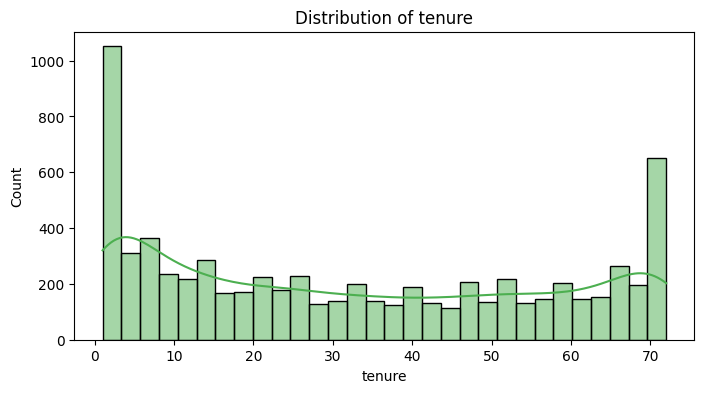

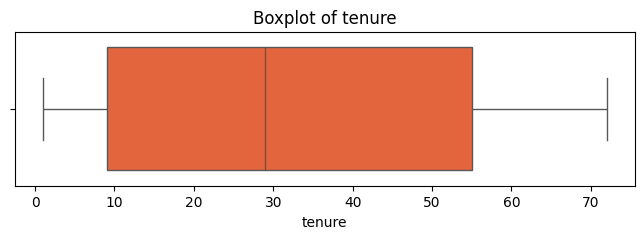

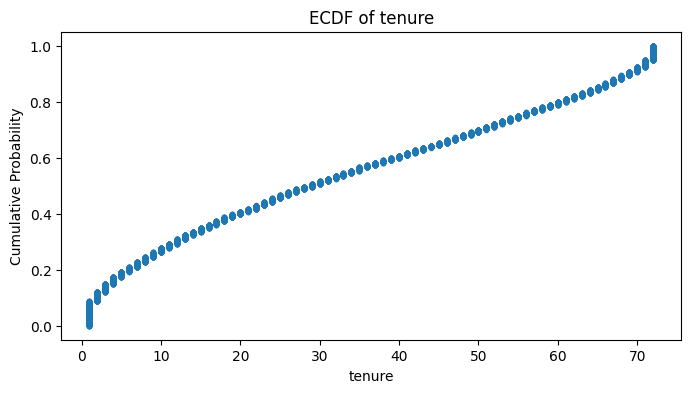

tenure stats:
count    7032.000000
mean       32.421786
std        24.545260
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64
Skewness: 0.23773083190513133
-----

---------------------------------------------------------------------------------------------------------------------------
--- MonthlyCharges Distribution ---


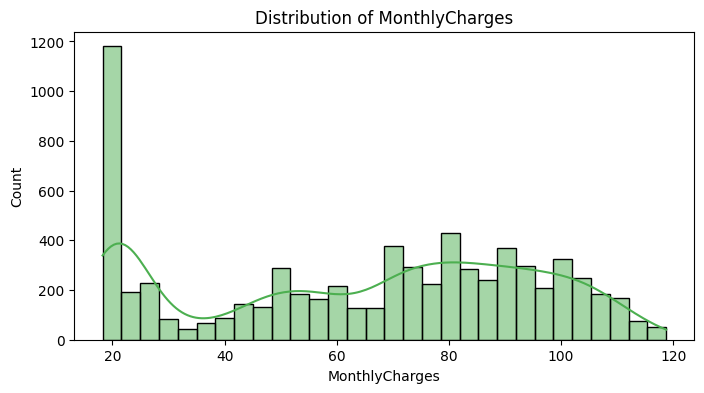

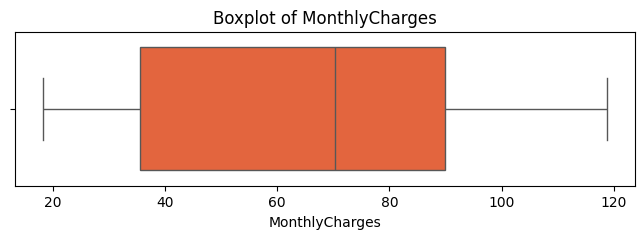

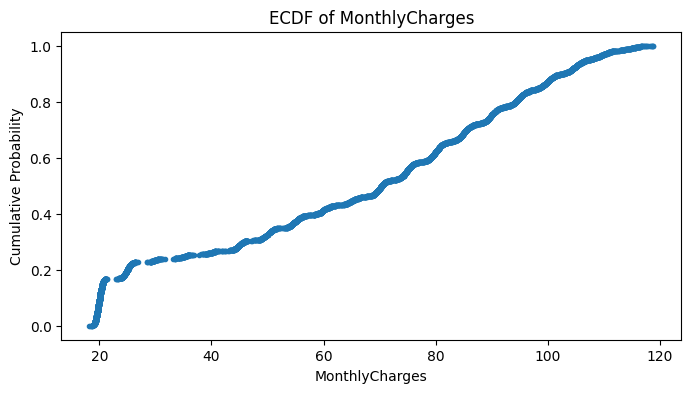

MonthlyCharges stats:
count    7032.000000
mean       64.798208
std        30.085974
min        18.250000
25%        35.587500
50%        70.350000
75%        89.862500
max       118.750000
Name: MonthlyCharges, dtype: float64
Skewness: -0.22210292770166232
-----

---------------------------------------------------------------------------------------------------------------------------
--- TotalCharges Distribution ---


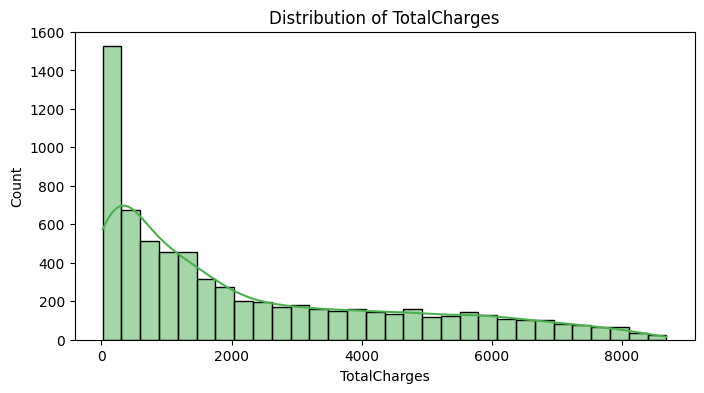

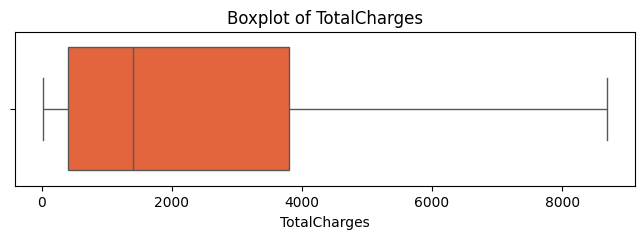

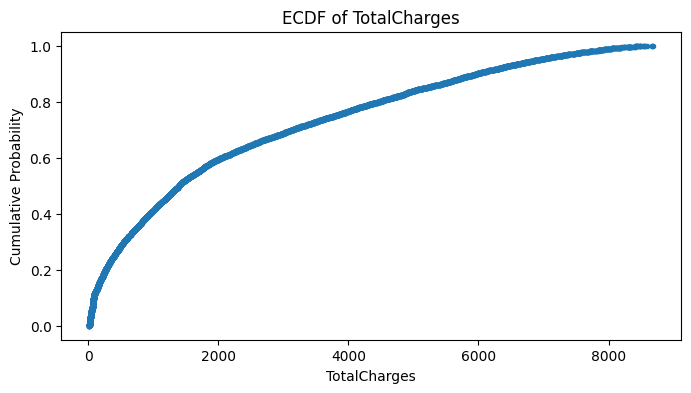

TotalCharges stats:
count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64
Skewness: 0.9616424997242504
-----



In [18]:
for col in numeric_cols:
    print("---" * 41)
    print(f"--- {col} Distribution ---")

    # Histogram + KDE
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True, bins=30, color='#4CAF50')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

    # Boxplot to check spread & outliers
    plt.figure(figsize=(8,2))
    sns.boxplot(x=df[col], color='#FF5722')
    plt.title(f'Boxplot of {col}')
    plt.show()

    # ECDF plot
    from statsmodels.distributions.empirical_distribution import ECDF
    ecdf = ECDF(df[col].dropna())
    plt.figure(figsize=(8,4))
    plt.plot(ecdf.x, ecdf.y, marker='.', linestyle='none')
    plt.title(f'ECDF of {col}')
    plt.xlabel(col)
    plt.ylabel("Cumulative Probability")
    plt.show()

    # Quick stats
    print(f"{col} stats:")
    print(df[col].describe())
    print("Skewness:", df[col].skew())
    print("-----\n")


- `Tenure`: Right-skewed → many new customers, few long-term ones. Could create tenure bins later.
- `MonthlyCharges`: Fairly spread, slight right skew → some high-paying customers.
- `TotalCharges`: Very similar to Monthly × Tenure, right-skewed; may need log-transform for modeling if using algorithms sensitive to scale/skew.

# Categorical Columns

In [19]:
cat_cols = df.select_dtypes('object').columns
print("Categorical columns :" ,list(cat_cols))

Categorical columns : ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [39]:
def get_column_summary(df, columns, id_cols=None):
    """
    Displays value counts, percentages, countplots, pie charts, and churn % for categorical columns.
    """
    if id_cols:
        columns = [col for col in columns if col not in id_cols]

    for col in columns:
        print("---" * 41)

        # Value counts + percentages
        summary_df = pd.DataFrame({
            col: df[col].value_counts().index,
            f"{col}_counts": df[col].value_counts().values,
            f"{col}_percentage": df[col].value_counts(normalize=True).values * 100
        })
        print(f"{col} value counts & percentage")
        display(summary_df)

        # Countplot (Bar chart)
        fig, ax = plt.subplots(figsize=(8,4))
        sns.countplot(data=df, x=col, order=df[col].value_counts().index, color=sns.color_palette("Set2")[0], ax=ax)
        for p in ax.patches:
            ax.annotate(f"{p.get_height()}", (p.get_x()+p.get_width()/2., p.get_height()),
                        ha='center', va='bottom')
        ax.set_title(f"{col} Count")
        plt.show()

        # Pie chart
        fig, ax = plt.subplots(figsize=(6,6))
        ax.pie(df[col].value_counts().values,
               labels=df[col].value_counts().index,
               autopct="%1.1f%%", startangle=90, colors=sns.color_palette("Set2"))
        ax.set_title(f"{col} Proportion")
        plt.show()

        # Churn % table
        churn_pct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
        print(f"Churn % by {col}")
        display(churn_pct.round(2))

        # Stacked bar (Churn %)

        churn_pct_reset = churn_pct.reset_index()

        fig, ax = plt.subplots(figsize=(8,4))

        ax.barh(churn_pct_reset[col], churn_pct_reset['No'], color="#4CAF50", label="No Churn")
        ax.barh(churn_pct_reset[col], churn_pct_reset['Yes'], left=churn_pct_reset['No'],
                color="#F44336", label="Churn")

        for i, (no, yes) in enumerate(zip(churn_pct_reset['No'], churn_pct_reset['Yes'])):
            ax.text(no/2, i, f"{no:.1f}%", va='center', ha='center', color='white', fontsize=9)
            ax.text(no + yes/2, i, f"{yes:.1f}%", va='center', ha='center', color='white', fontsize=9)
        ax.set_xlabel("Percentage")
        ax.set_title(f"Churn % by {col}")
        ax.legend()
        plt.show()


---------------------------------------------------------------------------------------------------------------------------
gender value counts & percentage


,gender,gender_counts,gender_percentage
0,Male,3549,50.469283
1,Female,3483,49.530717


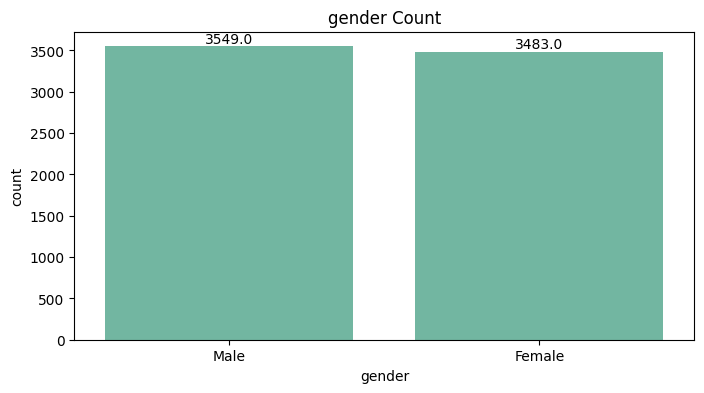

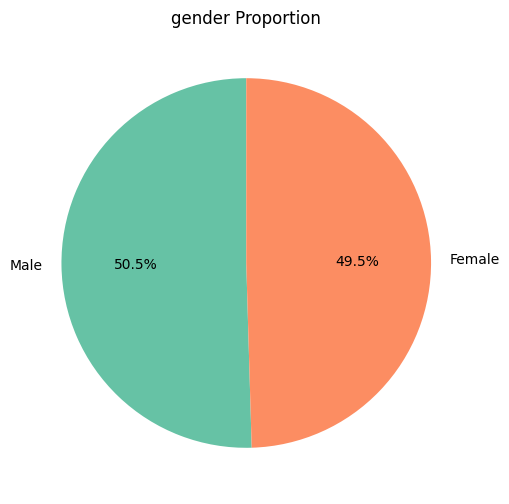

Churn % by gender


Churn,No,Yes
gender,,
Female,73.04,26.96
Male,73.80,26.20


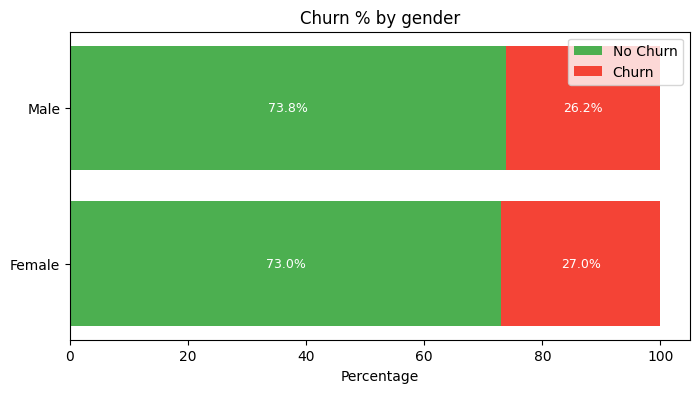

---------------------------------------------------------------------------------------------------------------------------
SeniorCitizen value counts & percentage


,SeniorCitizen,SeniorCitizen_counts,SeniorCitizen_percentage
0,0,5890,83.759954
1,1,1142,16.240046


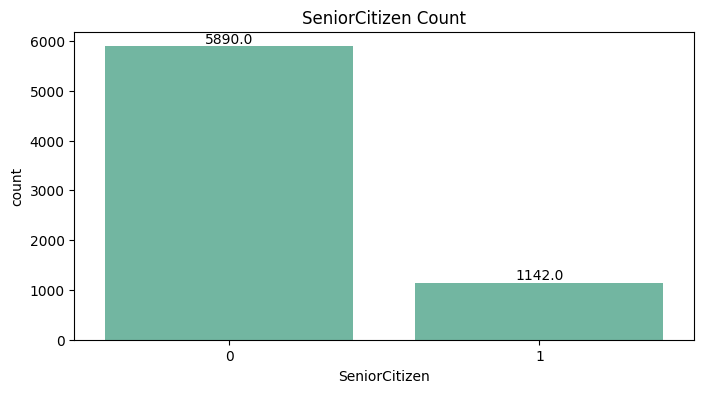

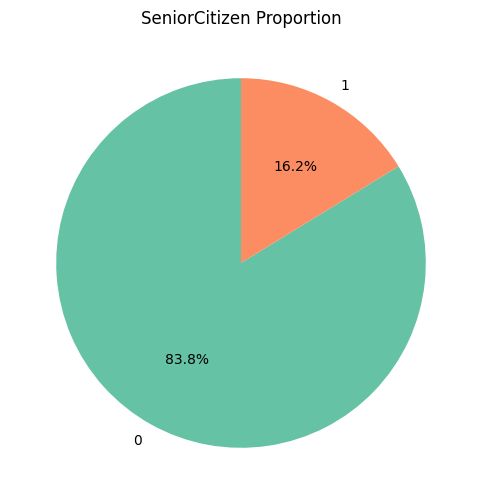

Churn % by SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
0,76.35,23.65
1,58.32,41.68


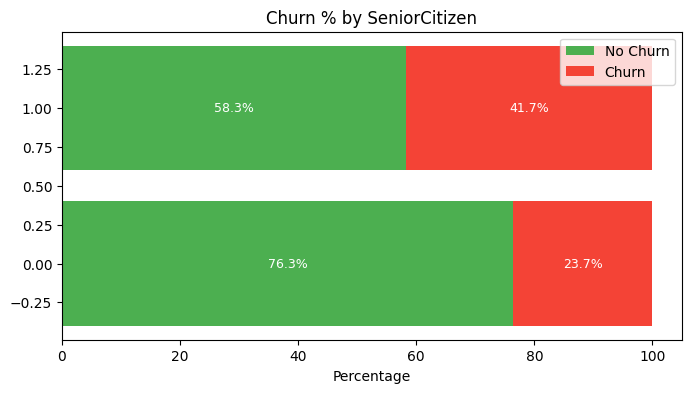

---------------------------------------------------------------------------------------------------------------------------
Partner value counts & percentage


,Partner,Partner_counts,Partner_percentage
0,No,3639,51.749147
1,Yes,3393,48.250853


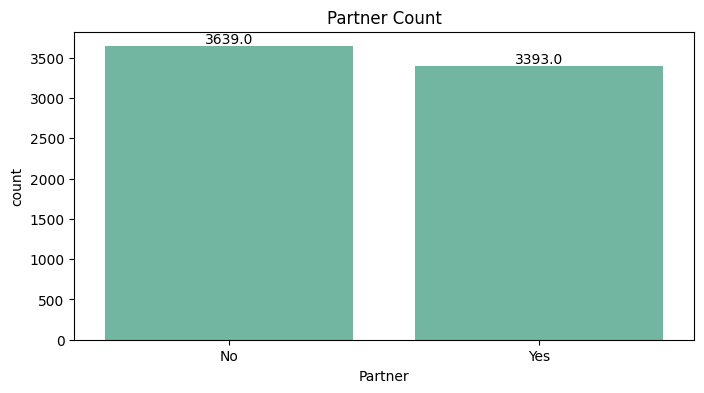

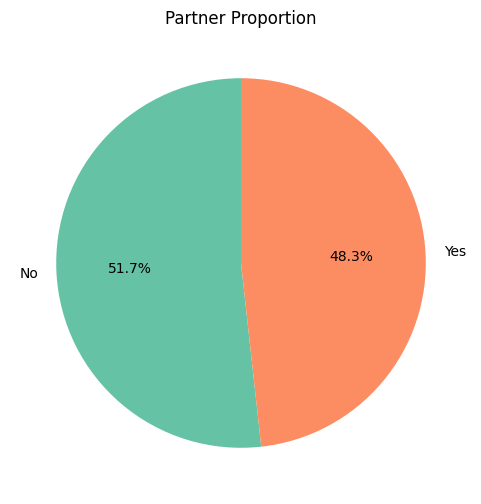

Churn % by Partner


Churn,No,Yes
Partner,,
No,67.02,32.98
Yes,80.28,19.72


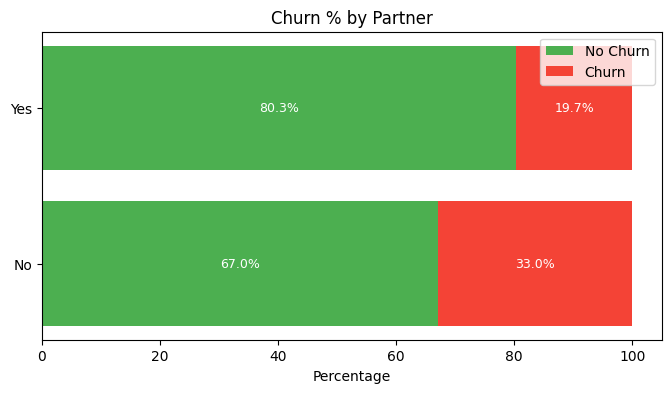

---------------------------------------------------------------------------------------------------------------------------
Dependents value counts & percentage


,Dependents,Dependents_counts,Dependents_percentage
0,No,4933,70.150739
1,Yes,2099,29.849261


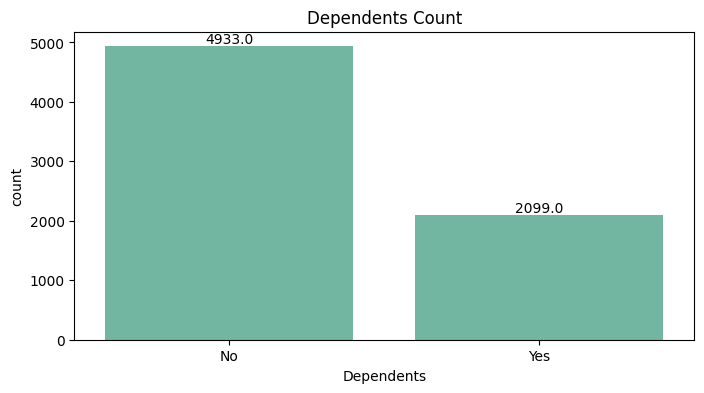

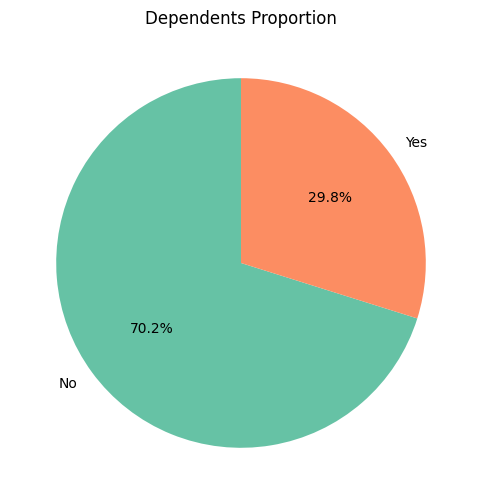

Churn % by Dependents


Churn,No,Yes
Dependents,,
No,68.72,31.28
Yes,84.47,15.53


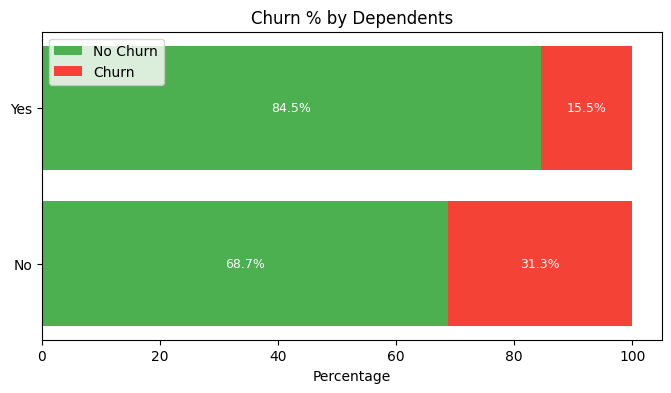

---------------------------------------------------------------------------------------------------------------------------
PhoneService value counts & percentage


,PhoneService,PhoneService_counts,PhoneService_percentage
0,Yes,6352,90.32992
1,No,680,9.67008


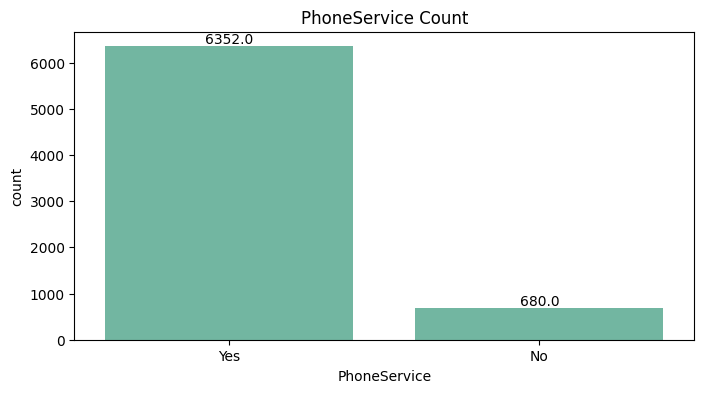

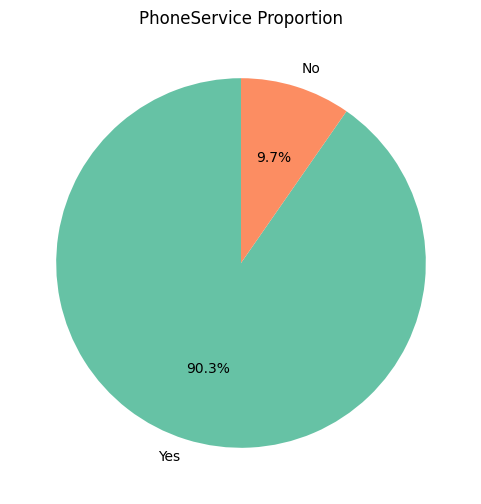

Churn % by PhoneService


Churn,No,Yes
PhoneService,,
No,75.00,25.00
Yes,73.25,26.75


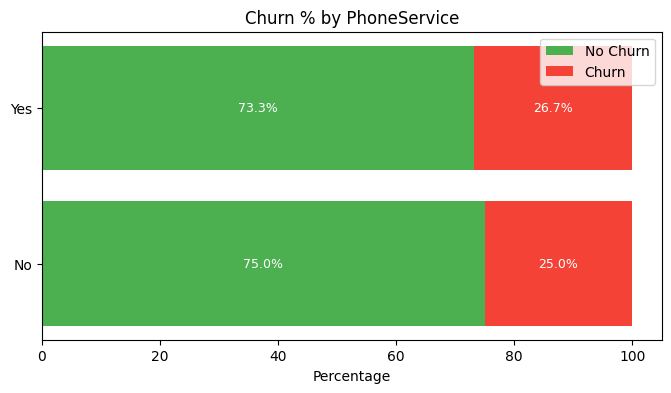

---------------------------------------------------------------------------------------------------------------------------
MultipleLines value counts & percentage


,MultipleLines,MultipleLines_counts,MultipleLines_percentage
0,No,3385,48.137088
1,Yes,2967,42.192833
2,No phone service,680,9.670080


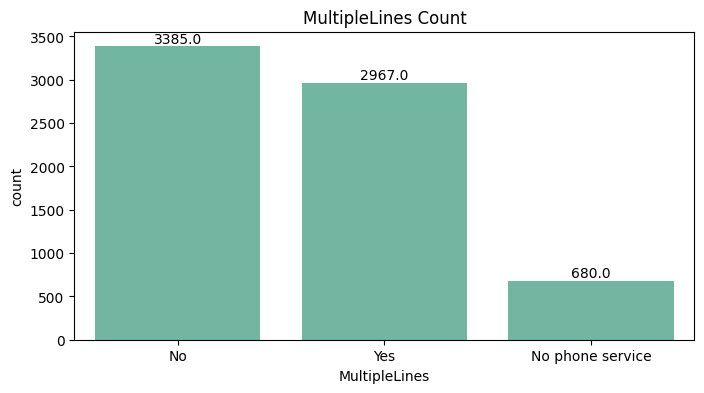

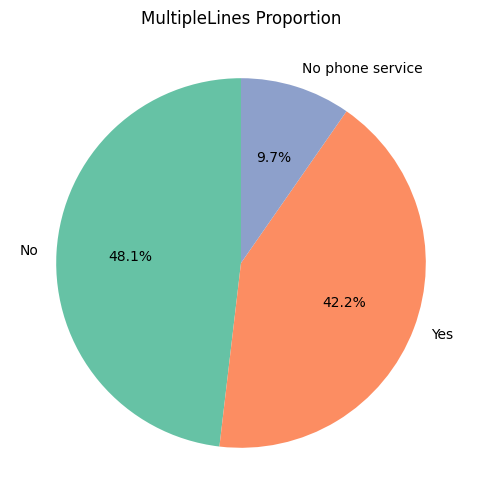

Churn % by MultipleLines


Churn,No,Yes
MultipleLines,,
No,74.92,25.08
No phone service,75.00,25.00
Yes,71.35,28.65


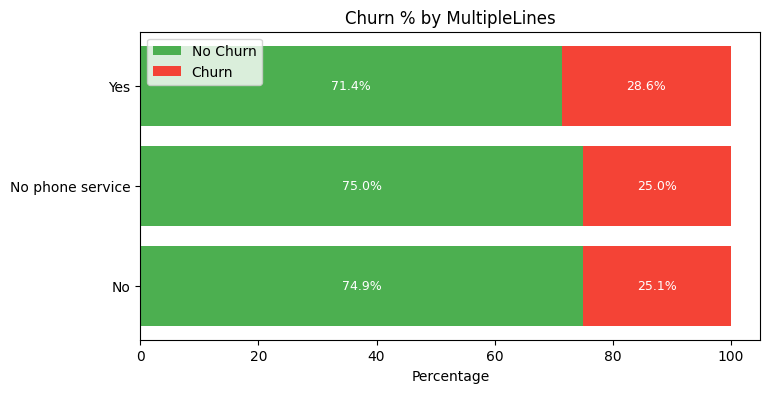

---------------------------------------------------------------------------------------------------------------------------
InternetService value counts & percentage


,InternetService,InternetService_counts,InternetService_percentage
0,Fiber optic,3096,44.027304
1,DSL,2416,34.357224
2,No,1520,21.615472


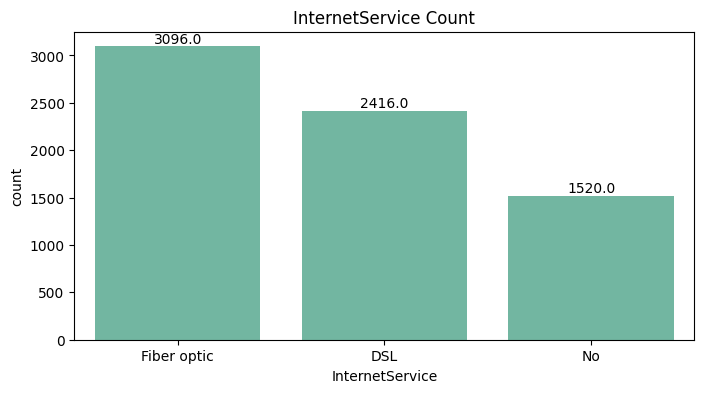

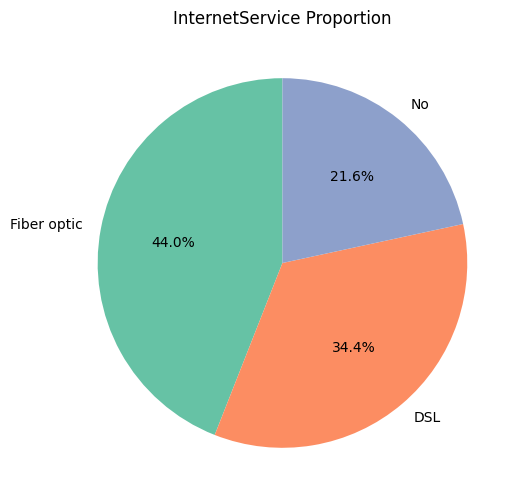

Churn % by InternetService


Churn,No,Yes
InternetService,,
DSL,81.00,19.00
Fiber optic,58.11,41.89
No,92.57,7.43


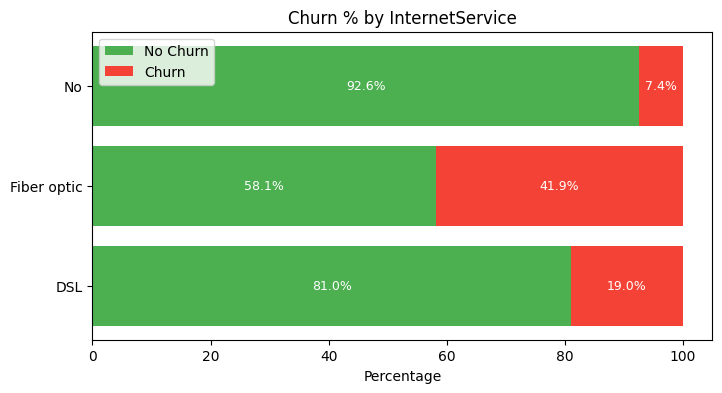

---------------------------------------------------------------------------------------------------------------------------
OnlineSecurity value counts & percentage


,OnlineSecurity,OnlineSecurity_counts,OnlineSecurity_percentage
0,No,3497,49.729807
1,Yes,2015,28.654721
2,No internet service,1520,21.615472


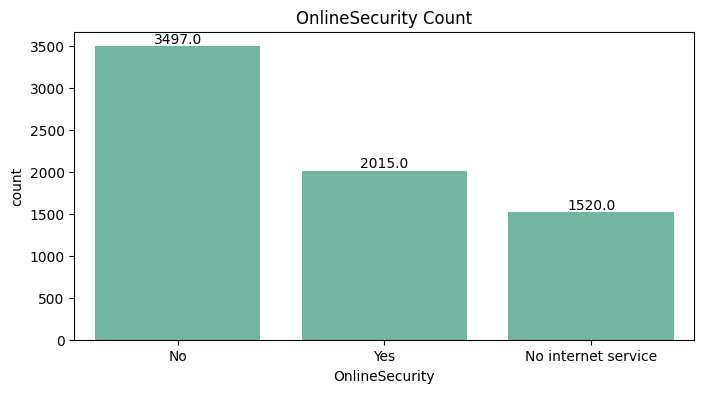

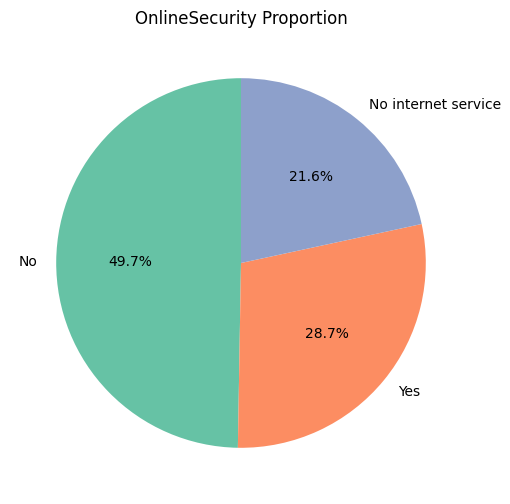

Churn % by OnlineSecurity


Churn,No,Yes
OnlineSecurity,,
No,58.22,41.78
No internet service,92.57,7.43
Yes,85.36,14.64


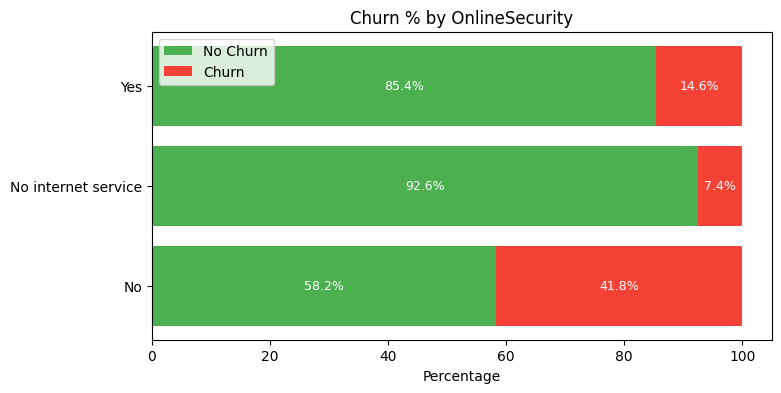

---------------------------------------------------------------------------------------------------------------------------
OnlineBackup value counts & percentage


,OnlineBackup,OnlineBackup_counts,OnlineBackup_percentage
0,No,3087,43.899317
1,Yes,2425,34.485210
2,No internet service,1520,21.615472


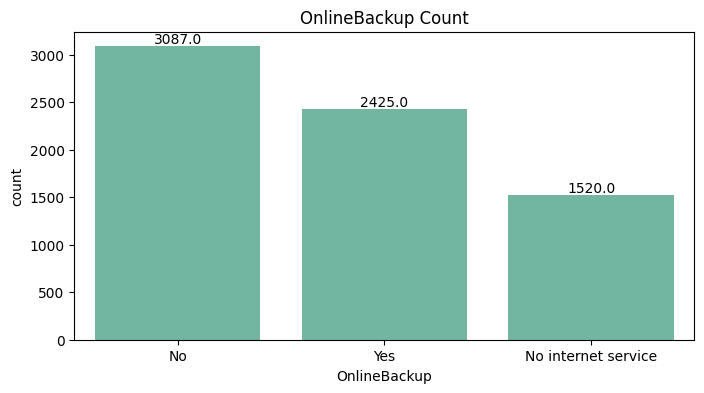

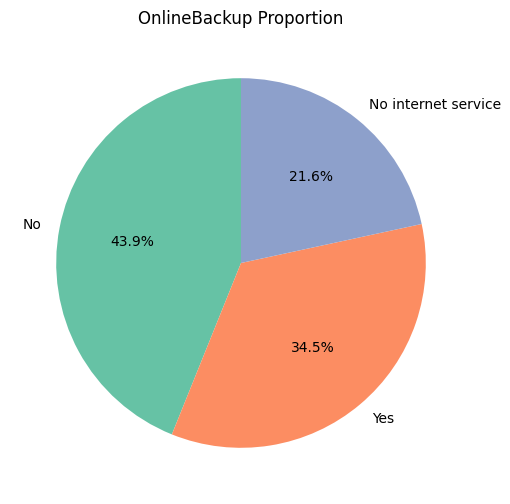

Churn % by OnlineBackup


Churn,No,Yes
OnlineBackup,,
No,60.06,39.94
No internet service,92.57,7.43
Yes,78.43,21.57


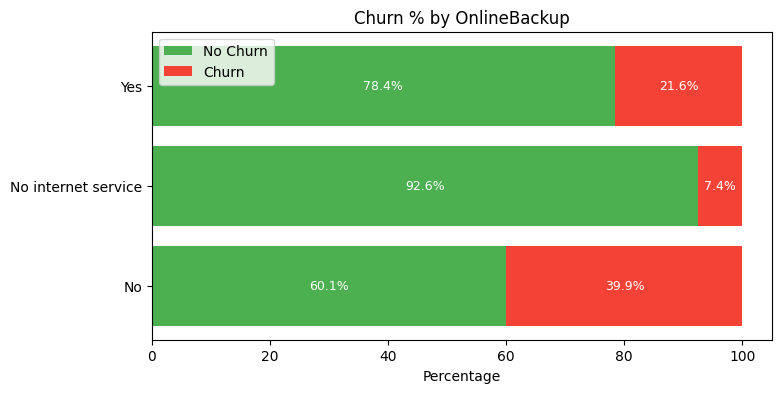

---------------------------------------------------------------------------------------------------------------------------
DeviceProtection value counts & percentage


,DeviceProtection,DeviceProtection_counts,DeviceProtection_percentage
0,No,3094,43.998862
1,Yes,2418,34.385666
2,No internet service,1520,21.615472


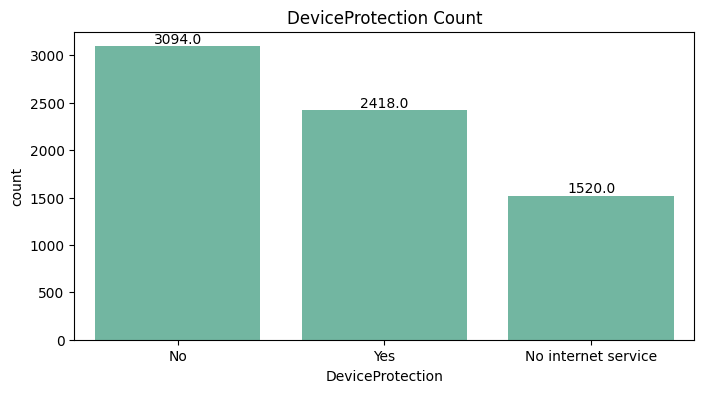

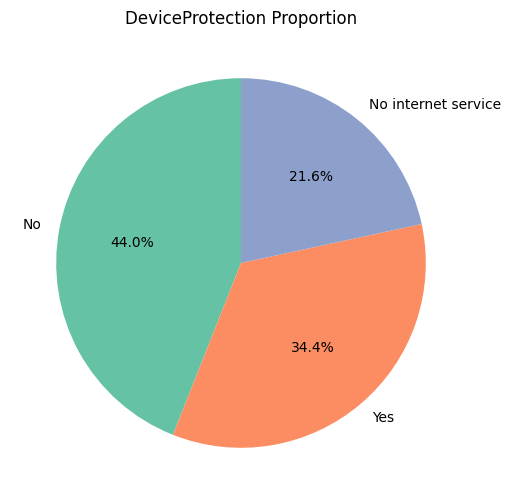

Churn % by DeviceProtection


Churn,No,Yes
DeviceProtection,,
No,60.86,39.14
No internet service,92.57,7.43
Yes,77.46,22.54


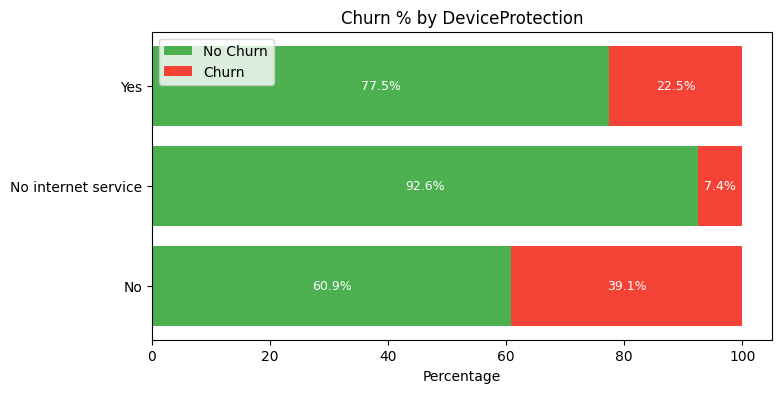

---------------------------------------------------------------------------------------------------------------------------
TechSupport value counts & percentage


,TechSupport,TechSupport_counts,TechSupport_percentage
0,No,3472,49.374289
1,Yes,2040,29.010239
2,No internet service,1520,21.615472


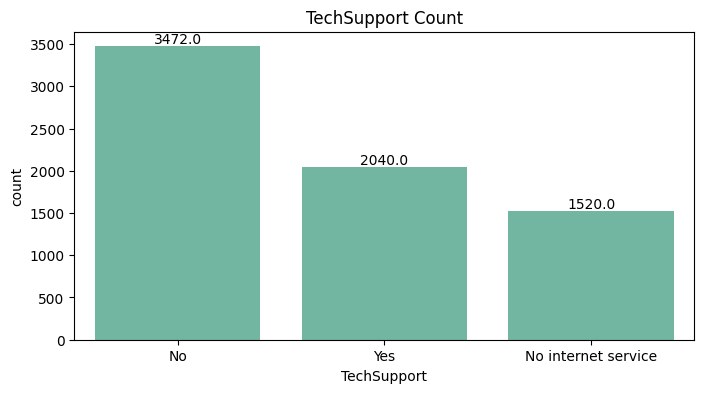

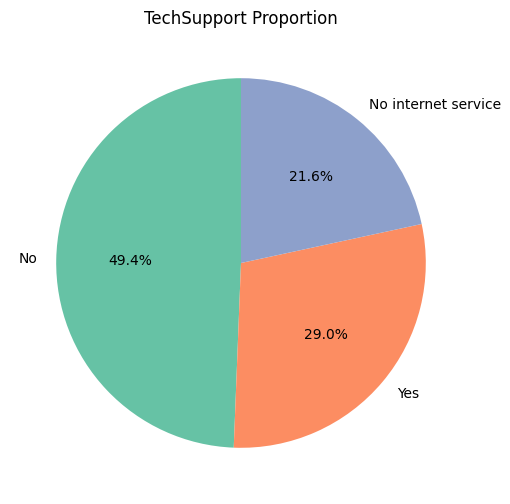

Churn % by TechSupport


Churn,No,Yes
TechSupport,,
No,58.35,41.65
No internet service,92.57,7.43
Yes,84.80,15.20


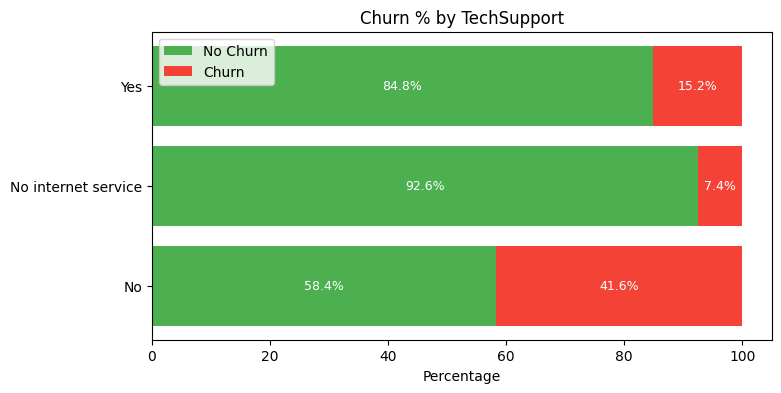

---------------------------------------------------------------------------------------------------------------------------
StreamingTV value counts & percentage


,StreamingTV,StreamingTV_counts,StreamingTV_percentage
0,No,2809,39.945961
1,Yes,2703,38.438567
2,No internet service,1520,21.615472


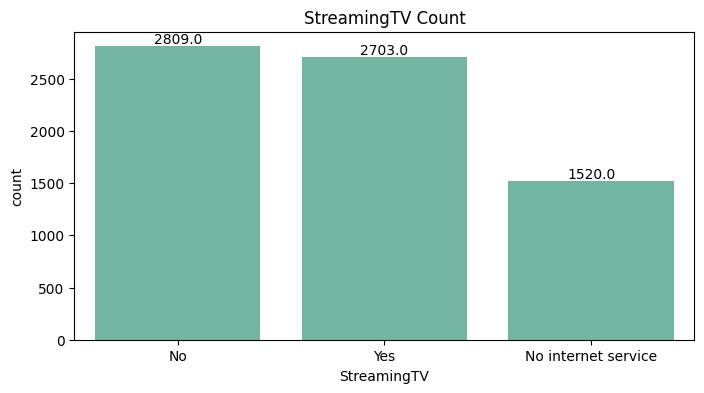

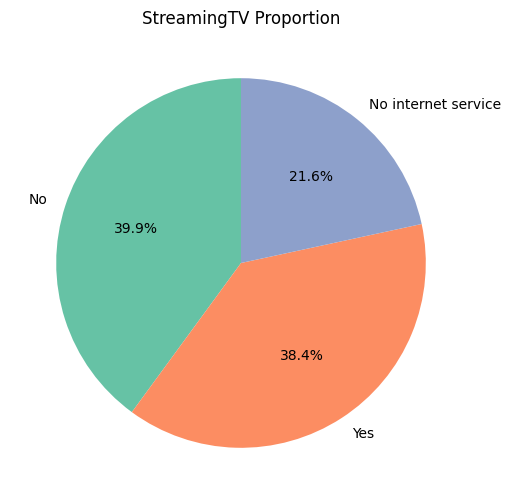

Churn % by StreamingTV


Churn,No,Yes
StreamingTV,,
No,66.46,33.54
No internet service,92.57,7.43
Yes,69.89,30.11


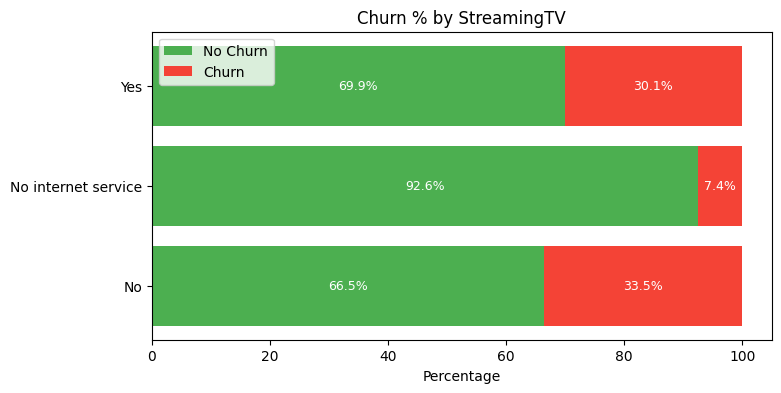

---------------------------------------------------------------------------------------------------------------------------
StreamingMovies value counts & percentage


,StreamingMovies,StreamingMovies_counts,StreamingMovies_percentage
0,No,2781,39.547782
1,Yes,2731,38.836746
2,No internet service,1520,21.615472


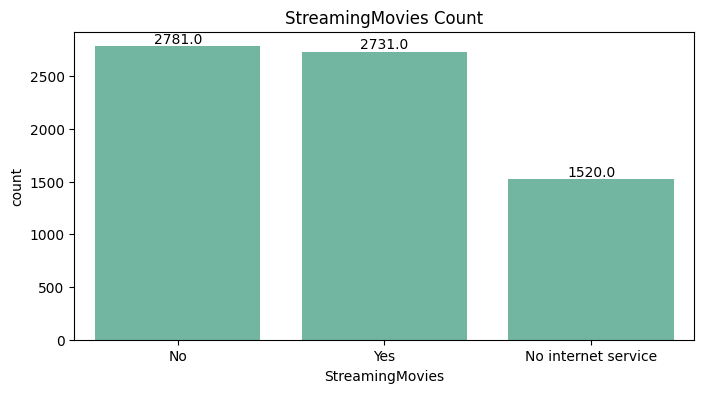

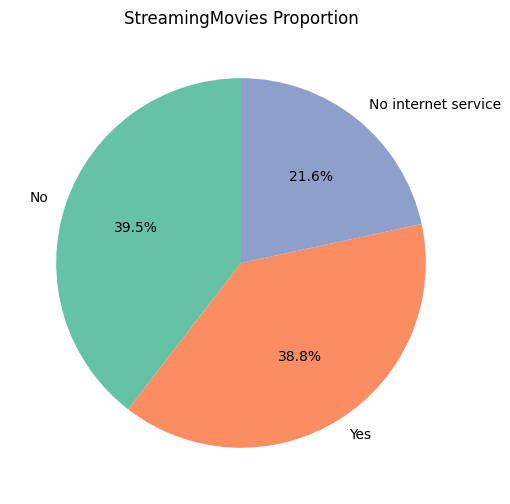

Churn % by StreamingMovies


Churn,No,Yes
StreamingMovies,,
No,66.27,33.73
No internet service,92.57,7.43
Yes,70.05,29.95


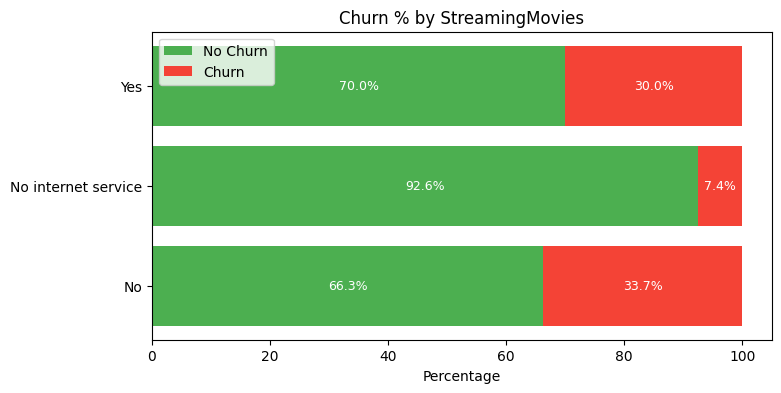

---------------------------------------------------------------------------------------------------------------------------
Contract value counts & percentage


,Contract,Contract_counts,Contract_percentage
0,Month-to-month,3875,55.105233
1,Two year,1685,23.961889
2,One year,1472,20.932878


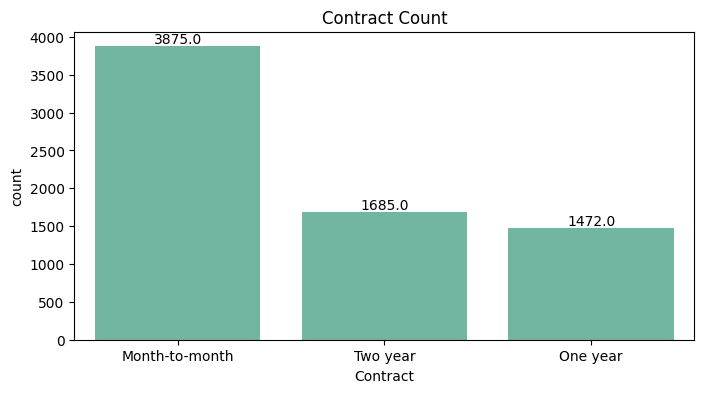

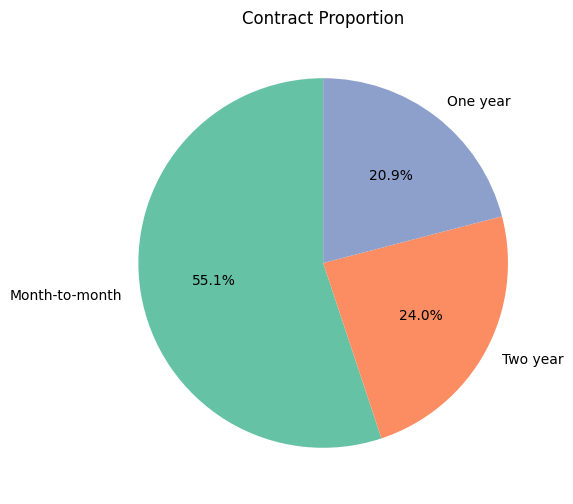

Churn % by Contract


Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.72,11.28
Two year,97.15,2.85


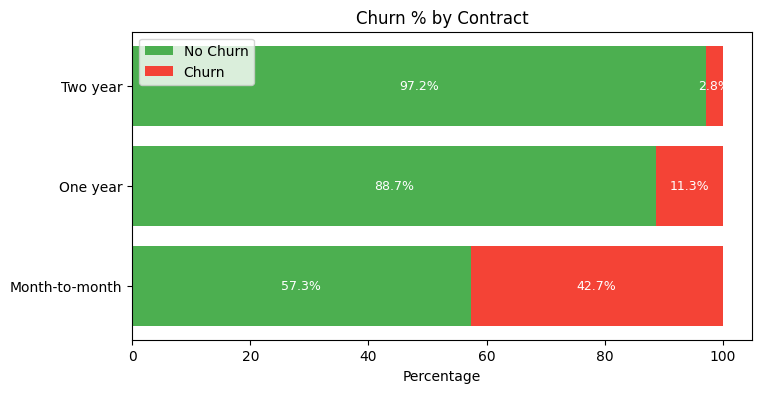

---------------------------------------------------------------------------------------------------------------------------
PaperlessBilling value counts & percentage


,PaperlessBilling,PaperlessBilling_counts,PaperlessBilling_percentage
0,Yes,4168,59.2719
1,No,2864,40.7281


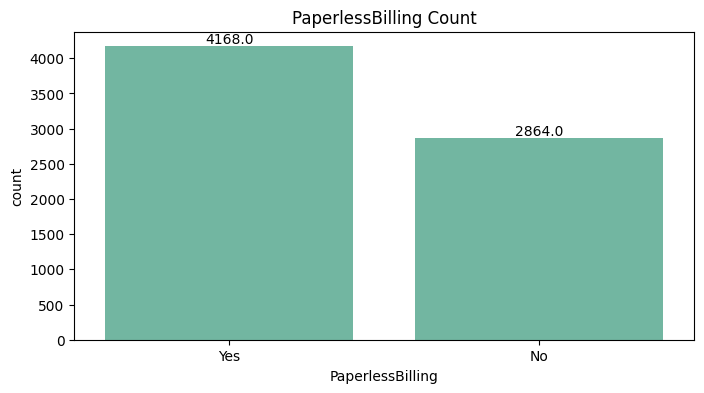

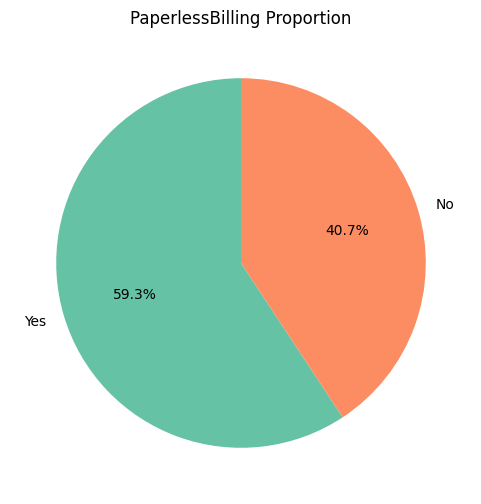

Churn % by PaperlessBilling


Churn,No,Yes
PaperlessBilling,,
No,83.62,16.38
Yes,66.41,33.59


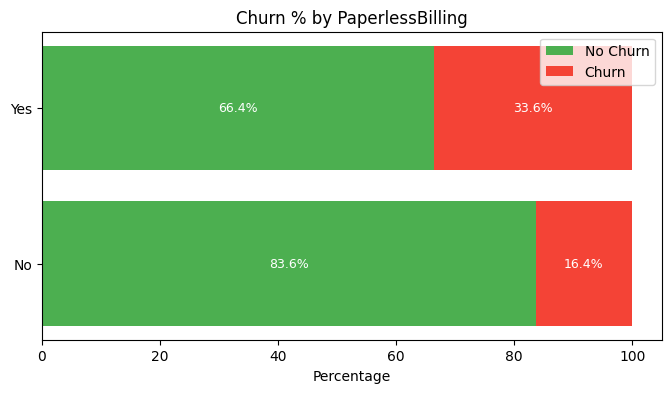

---------------------------------------------------------------------------------------------------------------------------
PaymentMethod value counts & percentage


,PaymentMethod,PaymentMethod_counts,PaymentMethod_percentage
0,Electronic check,2365,33.631968
1,Mailed check,1604,22.810011
2,Bank transfer (automatic),1542,21.928328
3,Credit card (automatic),1521,21.629693


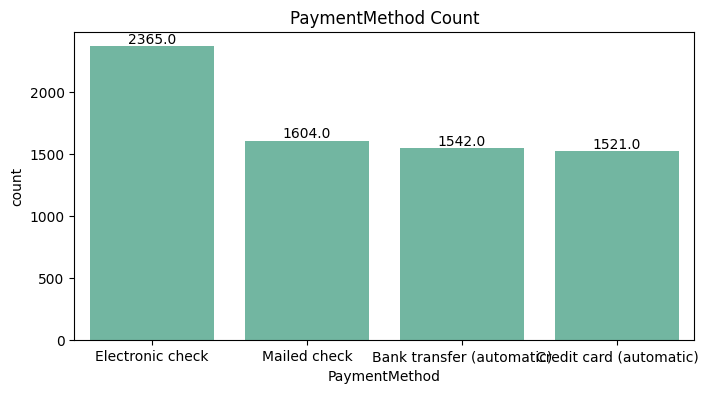

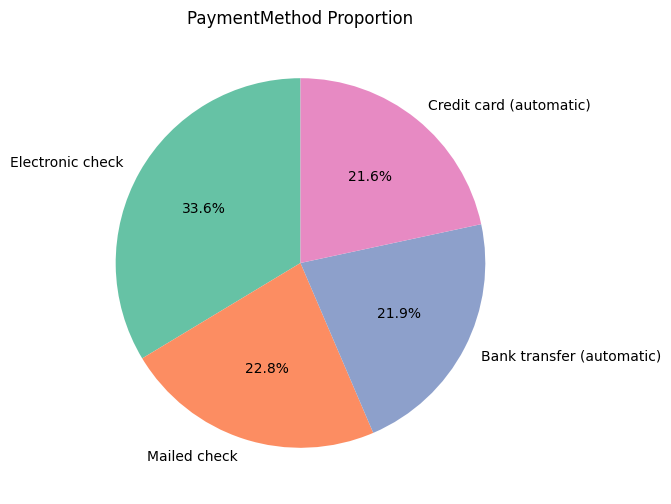

Churn % by PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.27,16.73
Credit card (automatic),84.75,15.25
Electronic check,54.71,45.29
Mailed check,80.80,19.20


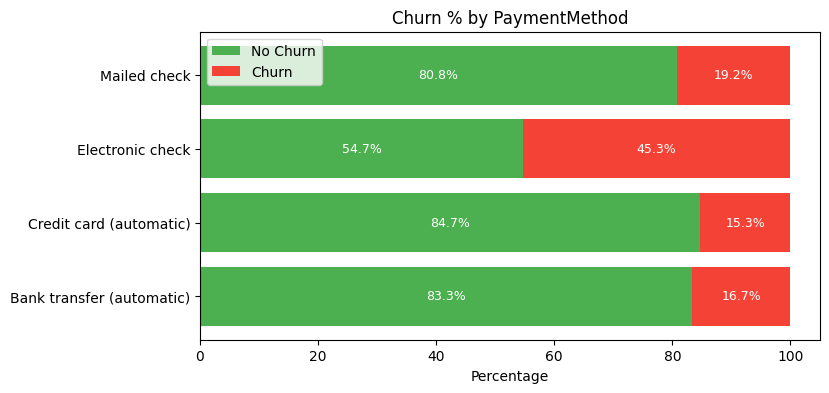

---------------------------------------------------------------------------------------------------------------------------
Churn value counts & percentage


,Churn,Churn_counts,Churn_percentage
0,No,5163,73.421502
1,Yes,1869,26.578498


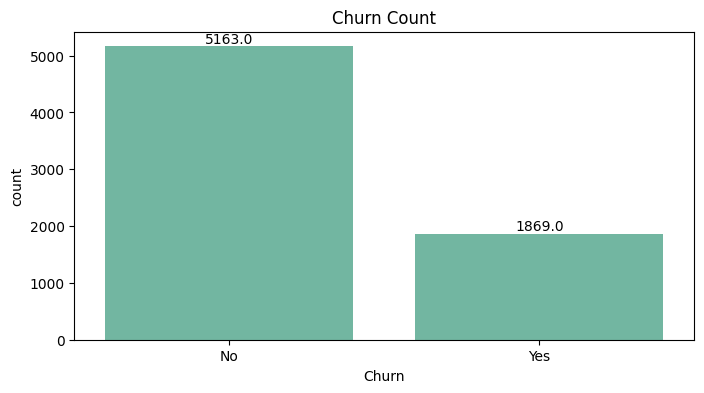

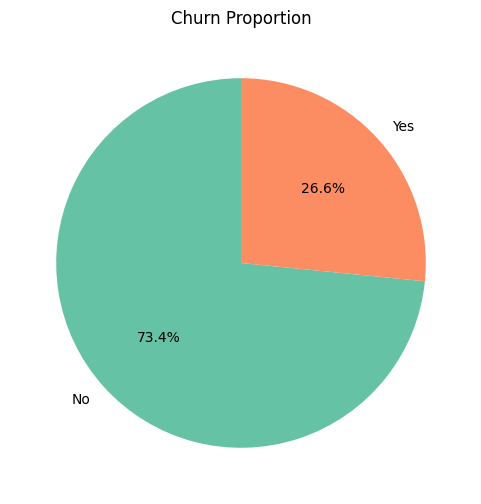

Churn % by Churn


Churn,No,Yes
Churn,,
No,100.0,0.0
Yes,0.0,100.0


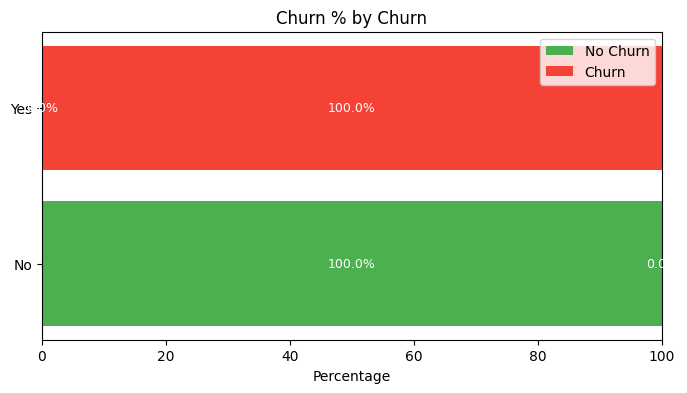

In [40]:
# Univariate analysis for categorical columns
get_column_summary(df ,cat_cols ,'customerID')

- `Contract type`: Month-to-month customers have highest churn → company should target with retention campaigns.
- `Payment method`: Electronic check users churn more → possible friction or convenience issue.
- `SeniorCitizen`: Slightly higher churn → opportunity for senior-friendly plans/support.
- `Family-related features (Partner, Dependents)`: Presence reduces churn → family customers are “stickier.”
- `Add-on services (OnlineSecurity, TechSupport, Streaming, etc.)`: Customers with more services churn less → cross-sell & bundle upsell opportunities.
- `Gender`: Minimal effect on churn → no targeted action needed.

## Outlier Detection and Handling

In [23]:
# Function for outlier detection
def detect_outliers(df , feature):
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)

    #Inter-quartile range
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[feature] < lower_bound ) | (df[feature] > upper_bound)]
    print(f"{feature} : {outliers.shape[0]} outliers detected ")
    return outliers , lower_bound ,upper_bound



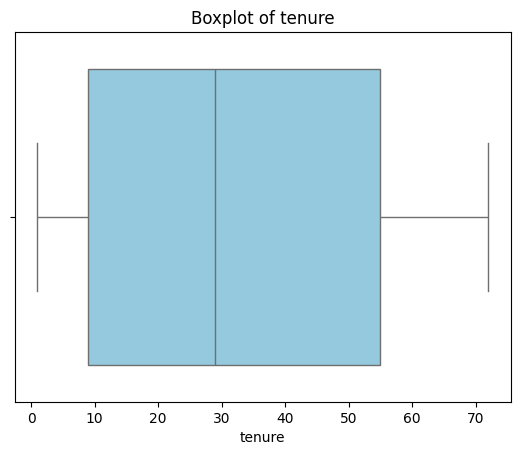

tenure : 0 outliers detected 
tenure → Lower Bound: -60.00, Upper Bound: 124.00
Found 0 outliers (0.00% of data)



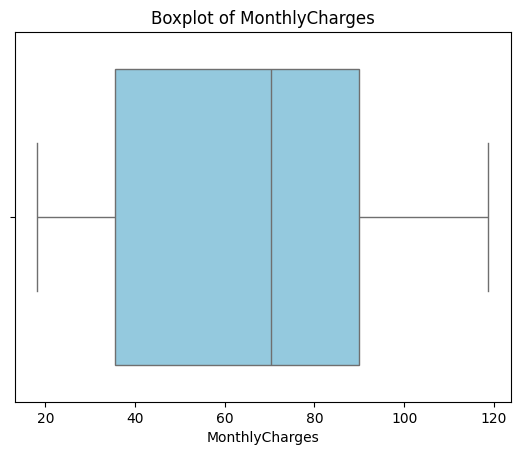

MonthlyCharges : 0 outliers detected 
MonthlyCharges → Lower Bound: -45.82, Upper Bound: 171.27
Found 0 outliers (0.00% of data)



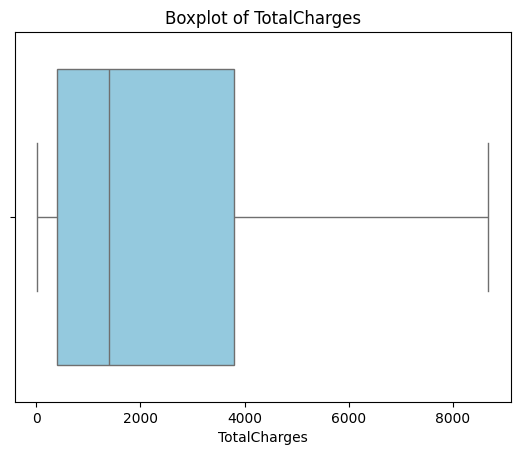

TotalCharges : 0 outliers detected 
TotalCharges → Lower Bound: -4688.48, Upper Bound: 8884.67
Found 0 outliers (0.00% of data)



In [24]:
# Plot boxplots + check outliers for each numeric column
for col in numeric_cols:
    sns.boxplot(x=df[col], color= 'skyblue')
    plt.title(f'Boxplot of {col}')
    plt.show()

    outliers, lb, ub = detect_outliers(df, col)
    print(f"{col} → Lower Bound: {lb:.2f}, Upper Bound: {ub:.2f}")
    print(f"Found {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}% of data)\n")


- Tenure: No outliers detected → all customers have tenure within a reasonable range (0–72 months).
- MonthlyCharges: No outliers detected → charges distribution is consistent with real plans.
- TotalCharges: No outliers detected → total revenue per customer is within realistic bounds.
- I don't need to remove or cap any data points — retained all rows for analysis.

# Bivariate Analysis (Categorical × Churn)


In [25]:
# Function to calculate churn percentage for a categorical column
def churn_percentage_table(df, col):
    return pd.crosstab(df[col], df['Churn'], normalize='index') * 100


---------------------------------------------------------------------------------------------------------------------------


Churn,No,Yes
gender,,
Female,73.04,26.96
Male,73.80,26.20


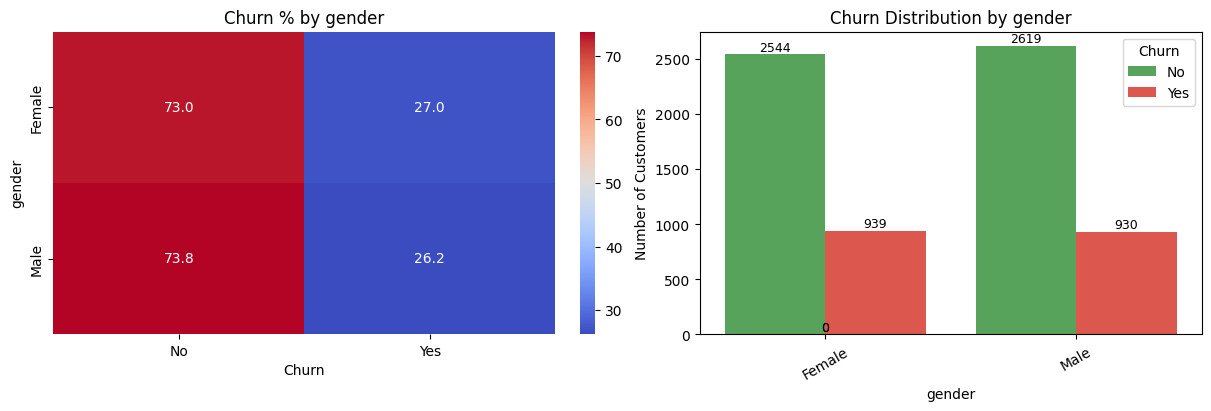

---------------------------------------------------------------------------------------------------------------------------


Churn,No,Yes
SeniorCitizen,,
0,76.35,23.65
1,58.32,41.68


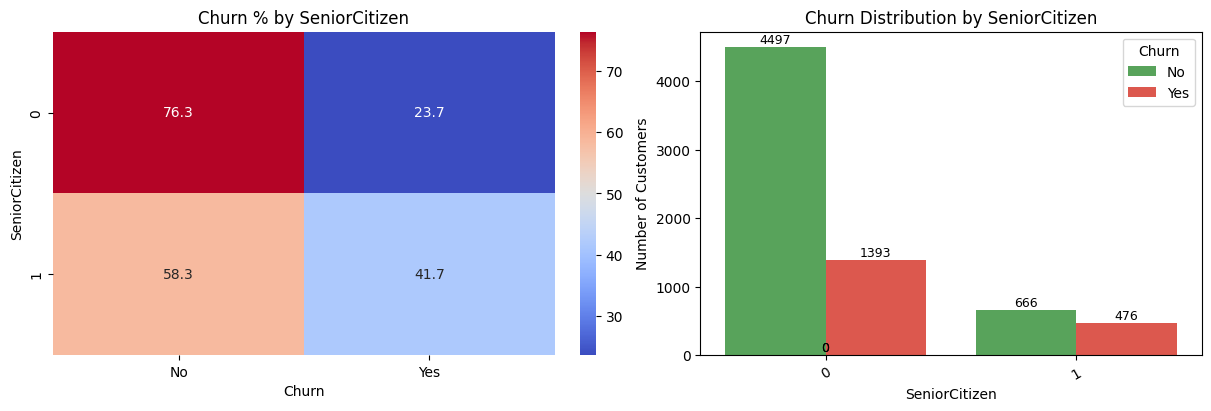

---------------------------------------------------------------------------------------------------------------------------


Churn,No,Yes
Partner,,
No,67.02,32.98
Yes,80.28,19.72


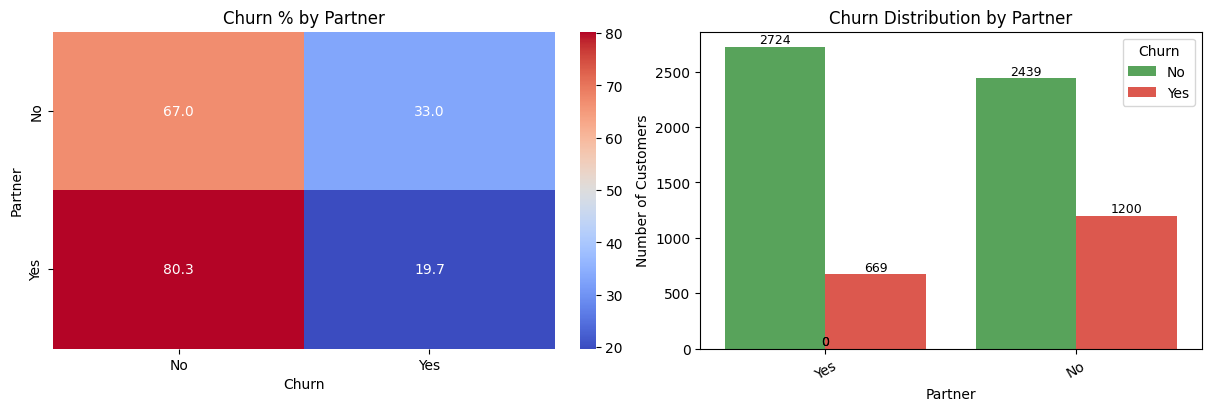

---------------------------------------------------------------------------------------------------------------------------


Churn,No,Yes
Dependents,,
No,68.72,31.28
Yes,84.47,15.53


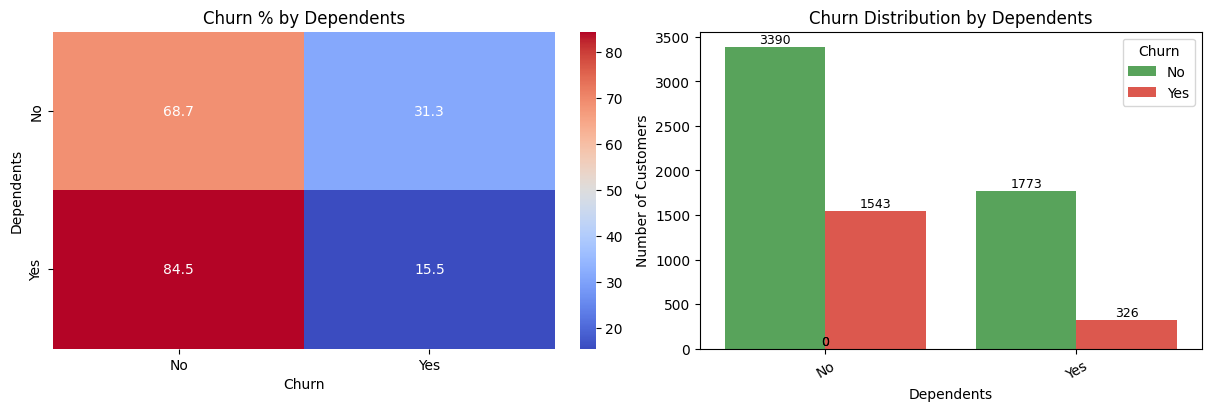

---------------------------------------------------------------------------------------------------------------------------


Churn,No,Yes
PhoneService,,
No,75.00,25.00
Yes,73.25,26.75


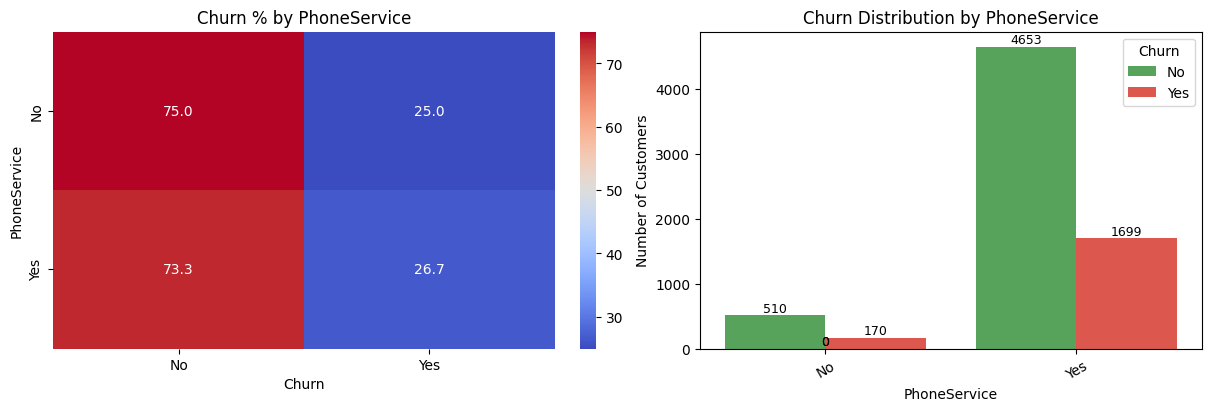

---------------------------------------------------------------------------------------------------------------------------


Churn,No,Yes
MultipleLines,,
No,74.92,25.08
No phone service,75.00,25.00
Yes,71.35,28.65


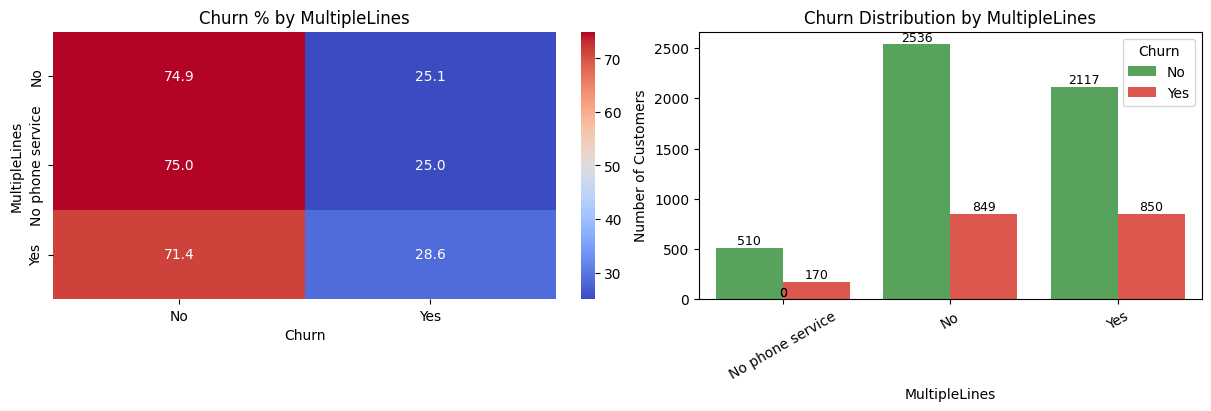

---------------------------------------------------------------------------------------------------------------------------


Churn,No,Yes
InternetService,,
DSL,81.00,19.00
Fiber optic,58.11,41.89
No,92.57,7.43


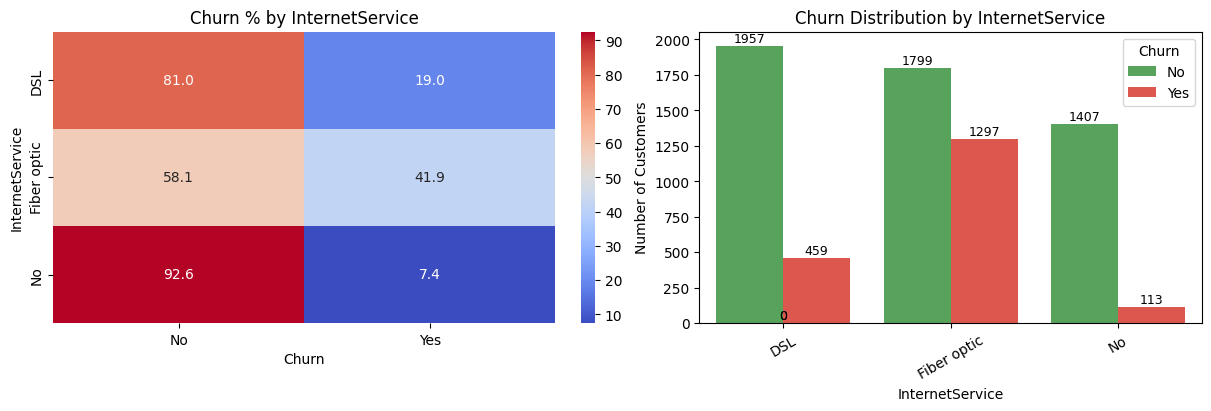

---------------------------------------------------------------------------------------------------------------------------


Churn,No,Yes
OnlineSecurity,,
No,58.22,41.78
No internet service,92.57,7.43
Yes,85.36,14.64


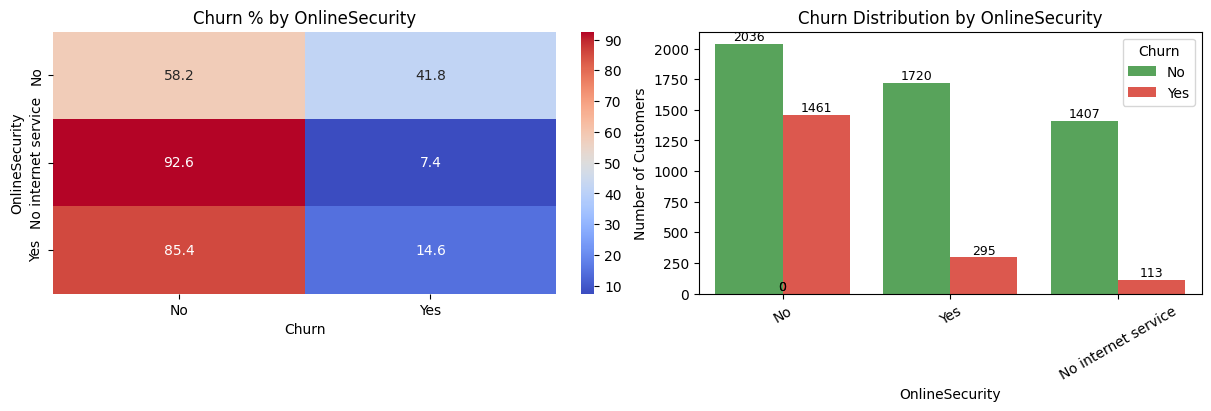

---------------------------------------------------------------------------------------------------------------------------


Churn,No,Yes
OnlineBackup,,
No,60.06,39.94
No internet service,92.57,7.43
Yes,78.43,21.57


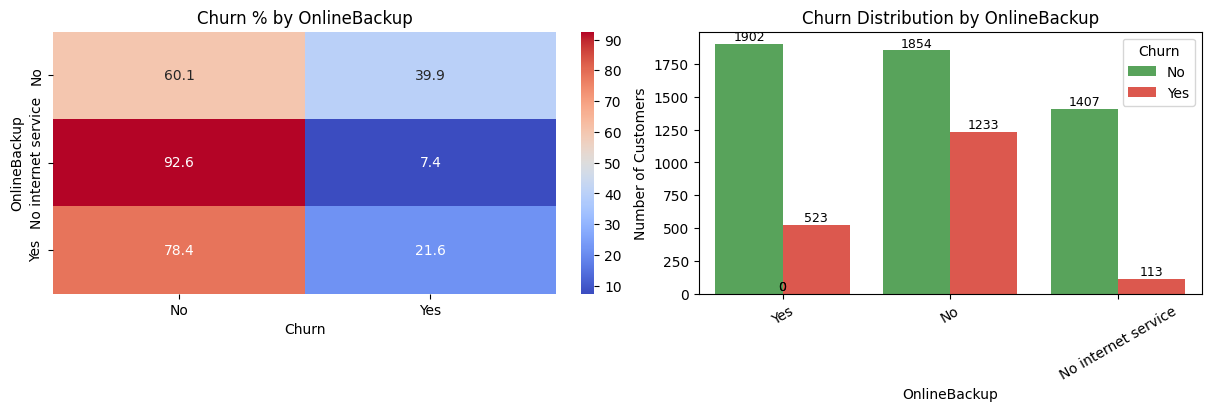

---------------------------------------------------------------------------------------------------------------------------


Churn,No,Yes
DeviceProtection,,
No,60.86,39.14
No internet service,92.57,7.43
Yes,77.46,22.54


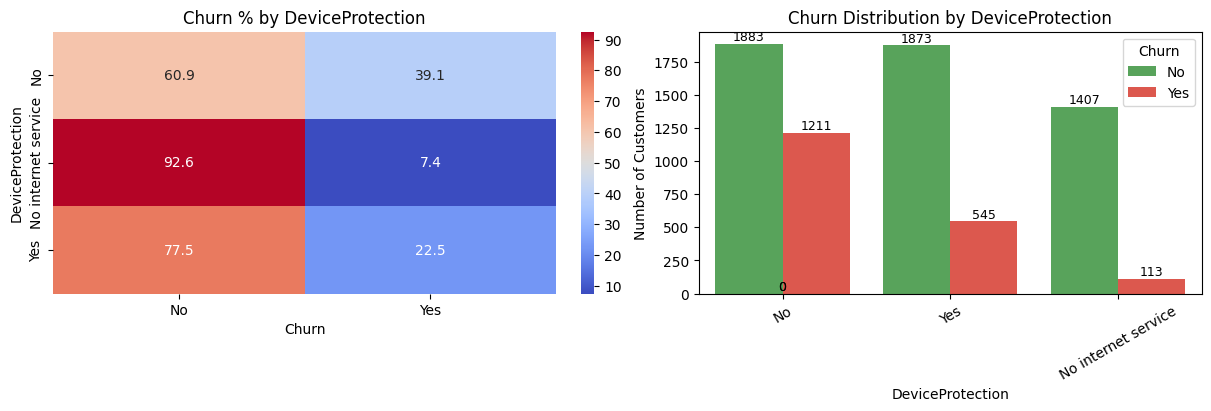

---------------------------------------------------------------------------------------------------------------------------


Churn,No,Yes
TechSupport,,
No,58.35,41.65
No internet service,92.57,7.43
Yes,84.80,15.20


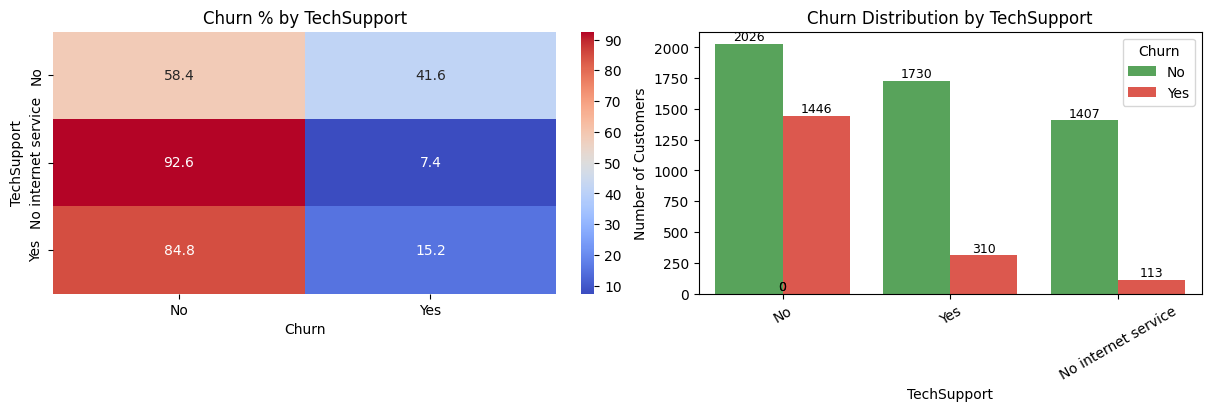

---------------------------------------------------------------------------------------------------------------------------


Churn,No,Yes
StreamingTV,,
No,66.46,33.54
No internet service,92.57,7.43
Yes,69.89,30.11


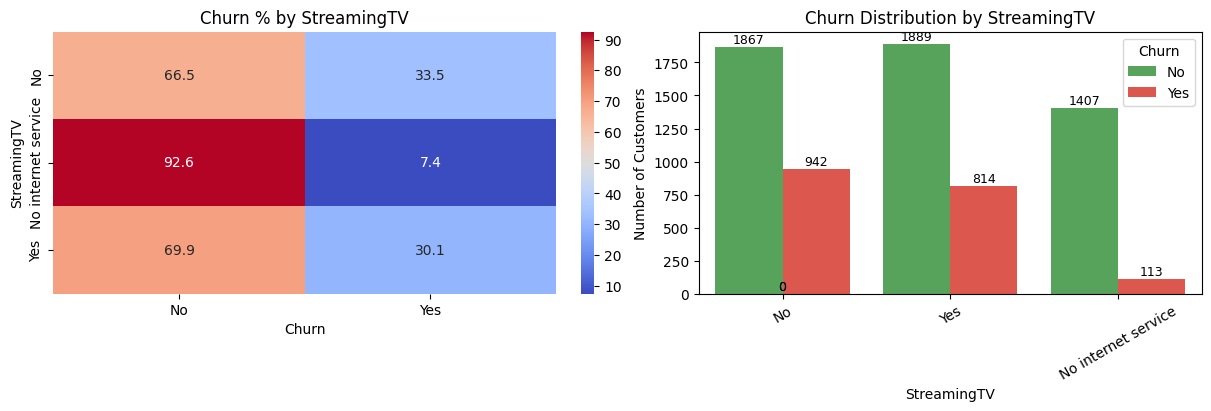

---------------------------------------------------------------------------------------------------------------------------


Churn,No,Yes
StreamingMovies,,
No,66.27,33.73
No internet service,92.57,7.43
Yes,70.05,29.95


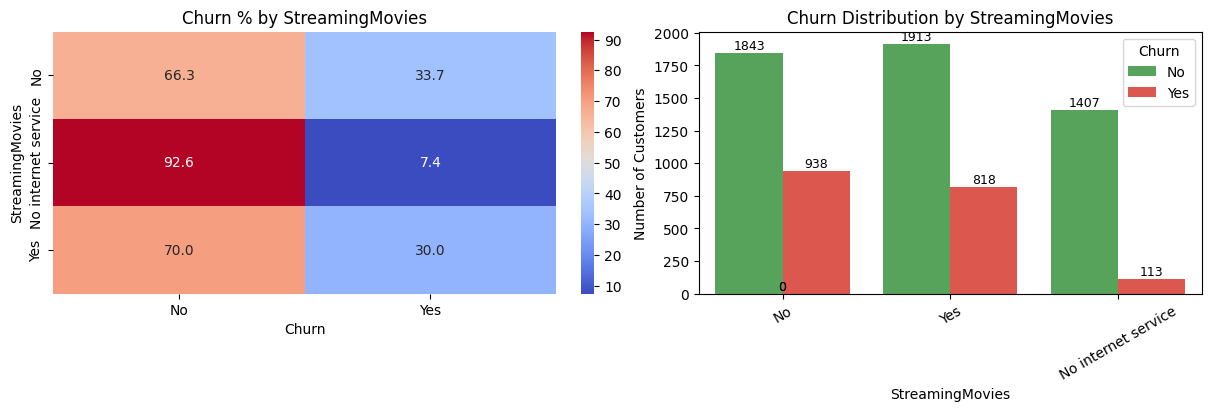

---------------------------------------------------------------------------------------------------------------------------


Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.72,11.28
Two year,97.15,2.85


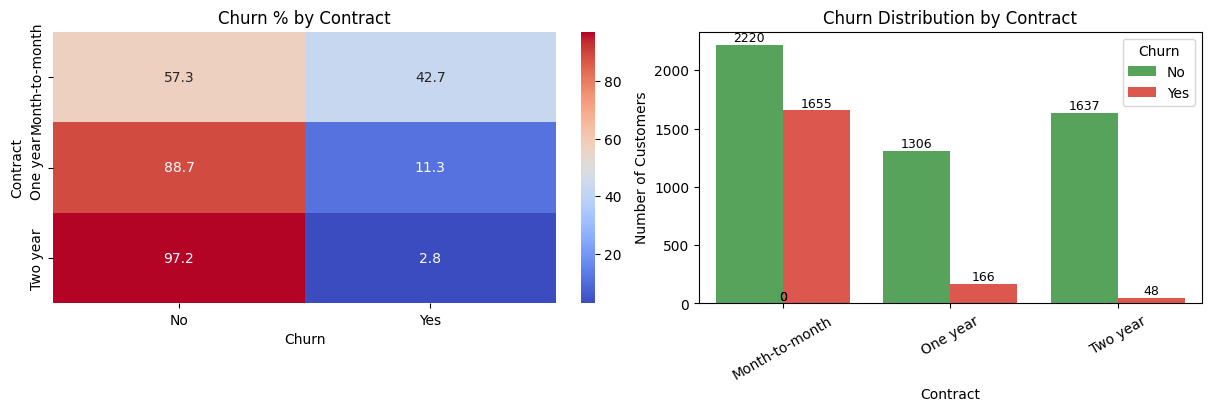

---------------------------------------------------------------------------------------------------------------------------


Churn,No,Yes
PaperlessBilling,,
No,83.62,16.38
Yes,66.41,33.59


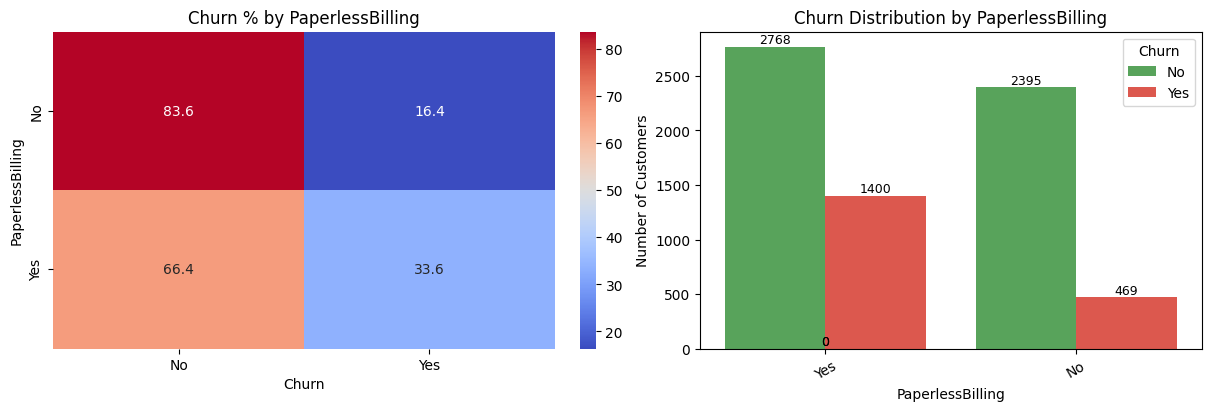

---------------------------------------------------------------------------------------------------------------------------


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.27,16.73
Credit card (automatic),84.75,15.25
Electronic check,54.71,45.29
Mailed check,80.80,19.20


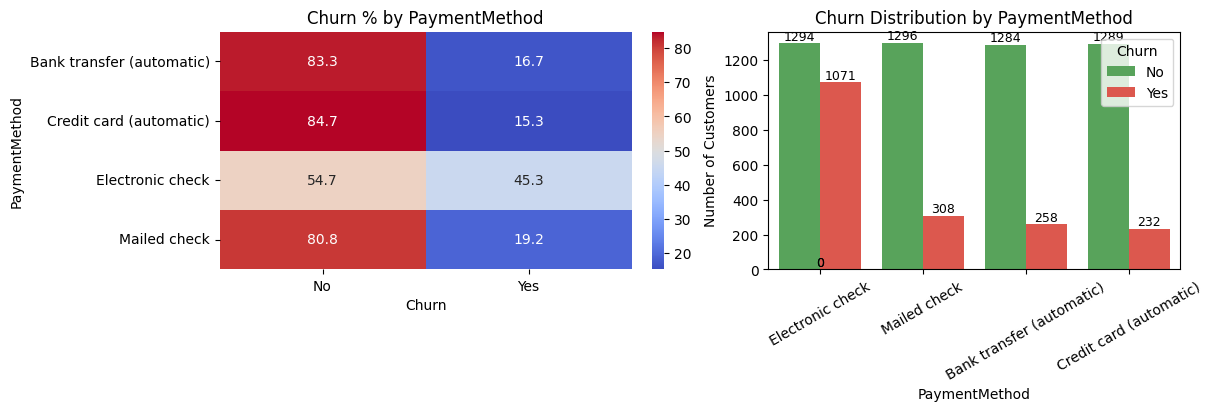

In [26]:
# Visualization for Each Categorical Column
from matplotlib.gridspec import GridSpec

for col in cat_cols[1:17]: # Excluded 'CustomerID' , 'Churn'
    print("---" * 41)
    churn_pct = churn_percentage_table(df, col)
    display(churn_pct.round(2))

    # subplot layout
    fig = plt.figure(constrained_layout=True, figsize=(12, 4))
    gs = GridSpec(1, 2, figure=fig)

    # Left plot - Heatmap (Churn %)
    ax1 = fig.add_subplot(gs[0, 0])
    sns.heatmap(churn_pct, annot=True, cmap="coolwarm", fmt=".1f", ax=ax1)
    ax1.set_title(f'Churn % by {col}')
    ax1.set_ylabel(col)
    ax1.set_xlabel('Churn')

    # Right plot - Countplot (Population)
    ax2 = fig.add_subplot(gs[0, 1])
    sns.countplot(data=df, x=col, hue='Churn', palette=['#4CAF50', '#F44336'], ax=ax2)
    ax2.set_title(f'Churn Distribution by {col}')
    ax2.set_xlabel(col)
    ax2.set_ylabel("Number of Customers")
    ax2.tick_params(axis='x' , rotation = 30)
    ax2.legend(title="Churn", loc='upper right')

    # Annotate counts on bars
    for p in ax2.patches:
        ax2.annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', fontsize=9, color='black', xytext=(0, 5),
                     textcoords='offset points')

    plt.show()


### Categorical Features (Insights)

> **Contract**  
> **Finding:** Month-to-month customers churn the most (≈ 42%) vs ≈ 11% for two-year contracts.  
> **Impact:** Majority of churners come from the month-to-month segment.  
> **Action:** Incentivize customers to switch to annual/two-year plans (discounted offers, loyalty points).

---

> **PaymentMethod**  
> **Finding:** Electronic check users have the highest churn rate (≈ 45%), much higher than automatic credit card/bank transfer users.  
> **Impact:** A big chunk of churn comes from this group.  
> **Action:** Investigate electronic check payment experience — reduce friction or incentivize users to switch to auto-pay.

---

> **InternetService**  
> **Finding:** Fiber optic users churn more compared to DSL users.  
> **Impact:** This is a large customer base — losing them affects revenue heavily.  
> **Action:** Investigate whether service quality, speed issues, or price dissatisfaction drive fiber churn.

---

> **OnlineSecurity, TechSupport, OnlineBackup**  
> **Finding:** Customers **without** these add-on services churn more.  
> **Impact:** Indicates these services have a retention effect.  
> **Action:** Bundle or upsell security/tech support packages to at-risk customers.

---

> **PaperlessBilling**  
> **Finding:** Slightly higher churn for paperless billing customers.  
> **Impact:** Could be tied to payment method effect.  
> **Action:** Explore cross-correlation with PaymentMethod — see if electronic check + paperless billing combination is problematic.

---

> **Partner & Dependents**  
> **Finding:** Customers with partners/dependents churn less.  
> **Impact:** Possibly due to higher service stickiness in families.  
> **Action:** Market “family bundles” or referral programs to increase retention.

---

> **Gender**  
> **Finding:** Male and female churn rates are almost identical.  
> **Impact:** Gender is not a churn driver.  
> **Action:** No gender-specific intervention needed.


# Bivariate Analysis (Numerical × Churn)

In [27]:
numeric_cols

Index(['tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

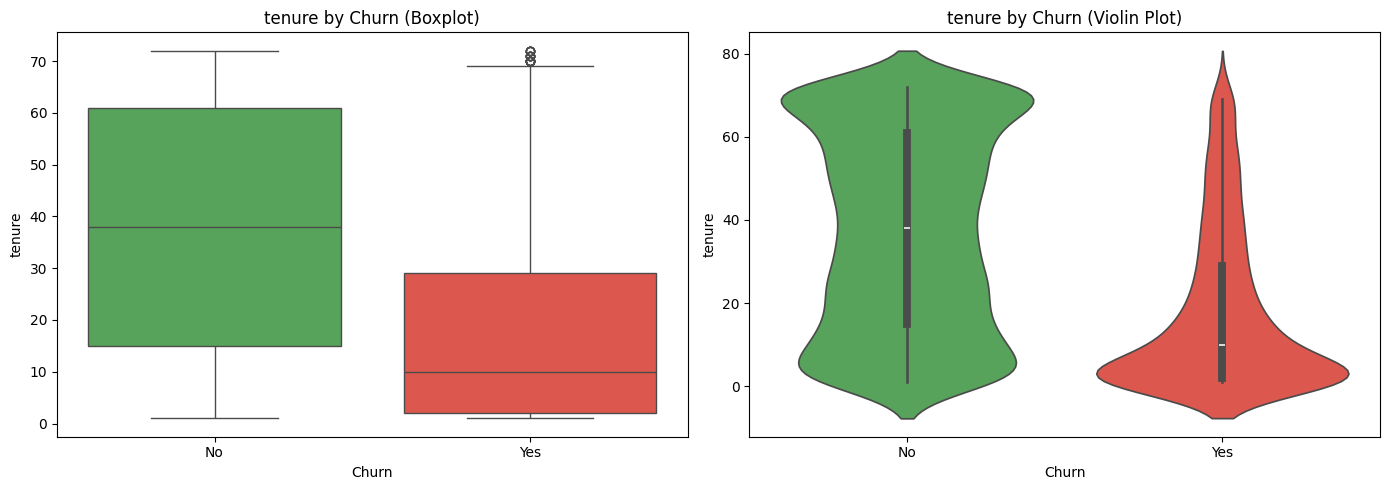

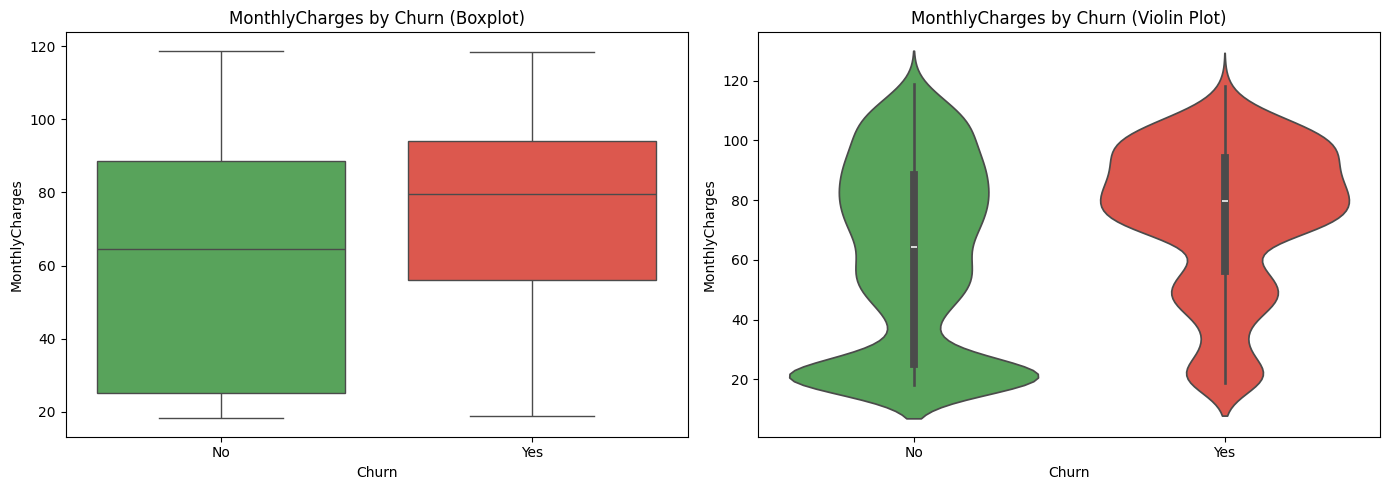

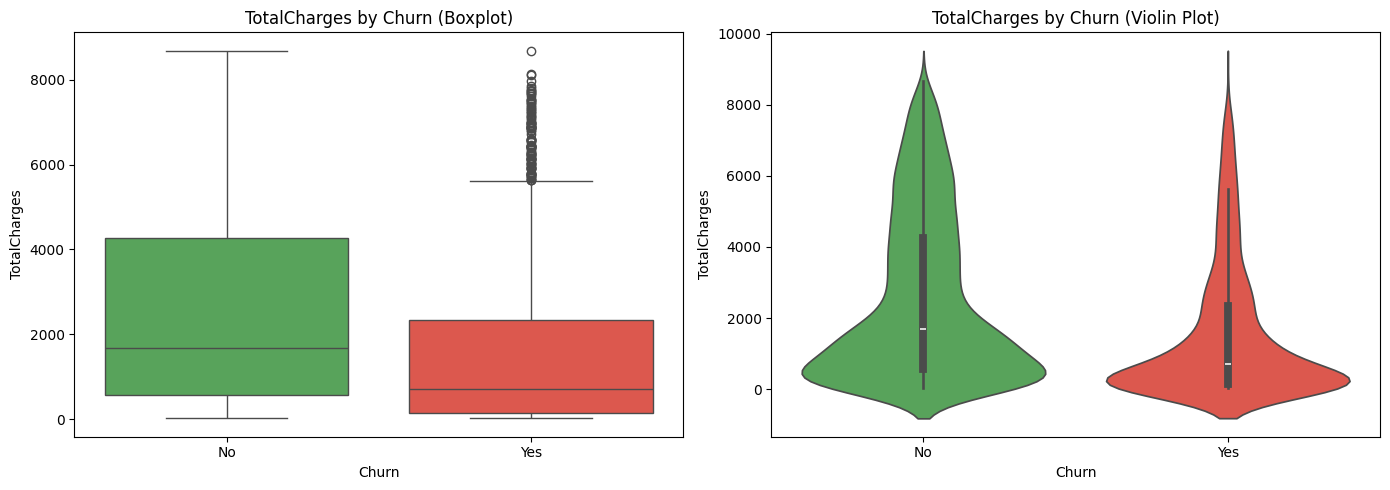

In [43]:
for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Boxplot
    sns.boxplot(ax=axes[0], x='Churn', y=col, data=df, hue='Churn',
                palette={'No':'#4CAF50', 'Yes':'#F44336'}, dodge=False)
    axes[0].set_title(f'{col} by Churn (Boxplot)')
    axes[0].set_xlabel("Churn")
    axes[0].set_ylabel(col)
    if axes[0].legend_:
        axes[0].legend_.remove()  # safely remove legend if it exists

    # Violin Plot
    sns.violinplot(ax=axes[1], x='Churn', y=col, data=df, hue='Churn',
                   palette={'No':'#4CAF50', 'Yes':'#F44336'}, dodge=False)
    axes[1].set_title(f'{col} by Churn (Violin Plot)')
    axes[1].set_xlabel("Churn")
    axes[1].set_ylabel(col)
    if axes[1].legend_:
        axes[1].legend_.remove()  # safely remove legend if it exists

    plt.tight_layout()
    plt.show()


**1 .Tenure**

- Customers with low tenure (0–12 months) have a significantly higher churn rate.
- Churn sharply decreases as tenure increases — long-term customers are more loyal.
- Early months are critical for retention efforts.

**2. MonthlyCharges**

- Higher monthly charges are associated with higher churn.
- Customers paying very high monthly fees seem more likely to leave, suggesting price sensitivity.
- Medium and lower-paying customers churn less, indicating perceived value is satisfactory.

**3. TotalCharges**

- Total charges generally follow tenure — new customers have lower total charges and higher churn.

- Some high-paying long-term customers also churn, which could indicate dissatisfaction or service issues despite loyalty.

# Statistical Hypothesis Testing

**Categorical Features** → Chi-Square Test of Independence

**Numerical Features** → Mann-Whitney U Test (safer than t-test for non-normal data)

In [29]:
# Hypothesis Testing
from scipy.stats import chi2_contingency, mannwhitneyu

print(" Chi-Square Test Results (Categorical Features):\n")
for col in cat_cols:
    table = pd.crosstab(df[col], df['Churn'])
    chi2, p, dof, expected = chi2_contingency(table)
    result = " Significant " if p < 0.05 else " Not Significant "
    print(f"{col:<20} p-value: {p:.4f} → {result}")

print("\n" + "-"*60 + "\n")

print(" Mann-Whitney U Test Results (Numerical Features):\n")
for col in numeric_cols:
    group_yes = df[df['Churn'] == 'Yes'][col]
    group_no  = df[df['Churn'] == 'No'][col]
    stat, p = mannwhitneyu(group_yes, group_no, alternative='two-sided')
    result = " Significant " if p < 0.05 else " Not Significant "
    print(f"{col:<20} p-value: {p:.4f} → {result}")


 Chi-Square Test Results (Categorical Features):

customerID           p-value: 0.4944 →  Not Significant 
gender               p-value: 0.4905 →  Not Significant 
SeniorCitizen        p-value: 0.0000 →  Significant 
Partner              p-value: 0.0000 →  Significant 
Dependents           p-value: 0.0000 →  Significant 
PhoneService         p-value: 0.3499 →  Not Significant 
MultipleLines        p-value: 0.0036 →  Significant 
InternetService      p-value: 0.0000 →  Significant 
OnlineSecurity       p-value: 0.0000 →  Significant 
OnlineBackup         p-value: 0.0000 →  Significant 
DeviceProtection     p-value: 0.0000 →  Significant 
TechSupport          p-value: 0.0000 →  Significant 
StreamingTV          p-value: 0.0000 →  Significant 
StreamingMovies      p-value: 0.0000 →  Significant 
Contract             p-value: 0.0000 →  Significant 
PaperlessBilling     p-value: 0.0000 →  Significant 
PaymentMethod        p-value: 0.0000 →  Significant 
Churn                p-value: 0.0000 

`Chi-Square Test`:

- Contract p-value = 0.0000  -- Strong association with churn
- PaymentMethod p-value = 0.0000  -- Significant churn driver
- Gender p-value = 0.5310  -- No significant effect

`Mann-Whitney U Test`:

- tenure p-value < 0.0001 -- Churned customers have significantly lower tenure -> early lifecycle problem
- MonthlyCharges p-value < 0.0001 -- High-charging customers churn more -> pricing sensitivity
-> TotalCharges p-value < 0.0001 -- Similar pattern as tenure

# Risk Segmentattion & Feature Interactions
Now that we know which features are statistically significant, let's explore **combinations of features** to find high-risk customer segments.


In [30]:
important_cats = ['Contract', 'PaymentMethod', 'InternetService',
                  'TechSupport', 'OnlineSecurity', 'Partner', 'Dependents']


## Why Focus on These Categorical Features?

Before we dive into pairwise interaction heatmaps, let's be intentional about **which features matter most**.  
We don't want to waste time plotting irrelevant combinations — instead, we'll focus on features that are both  
**statistically significant** and **business-relevant** for churn.

**How We Chose Important Columns:**
- **Statistical Evidence:** Our Chi-Square tests flagged these columns as significant (p < 0.05).
- **Business Relevance:** These features directly relate to customer stickiness, billing friction, or service type.
- **Strong Visual Patterns:** Earlier univariate/bivariate plots showed meaningful churn differences.

**Important Categorical Features We'll Analyze:**
- `Contract` – Strongest churn driver (month-to-month contracts churn the most)
- `PaymentMethod` – Electronic check users have higher churn
- `InternetService` – Fiber optic users churn more than DSL users
- `TechSupport` – Customers with tech support churn less (possible retention lever)
- `OnlineSecurity` – Another engagement feature, reduces churn risk
- `Partner` & `Dependents` – Proxies for customer stability (families churn differently than singles)

**Why We Skip Others:**
- `Gender` – No significant impact (p > 0.05).
- `customerID` – Just an identifier.
- `PhoneService` & `MultipleLines` – Weak churn signal compared to internet-related features.

By narrowing our focus, we make the next step **deep and meaningful**, not just "plotting for the sake of plotting."


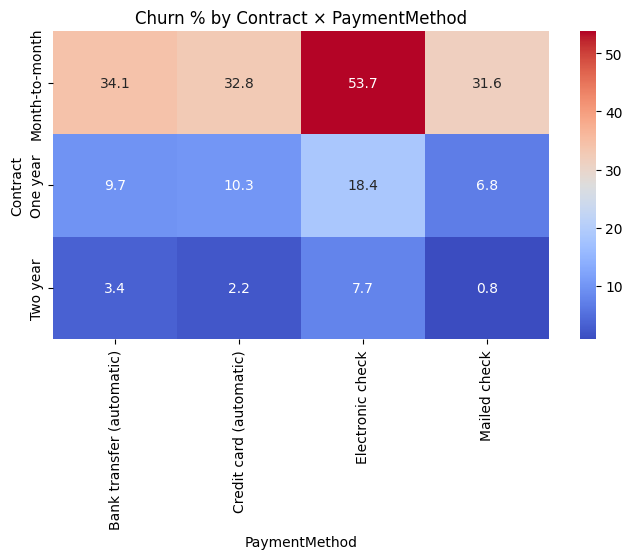

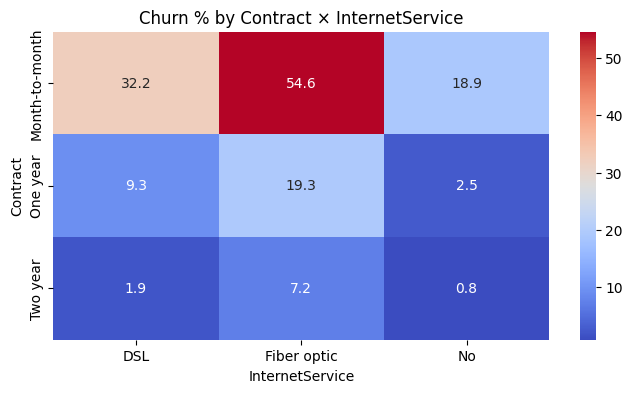

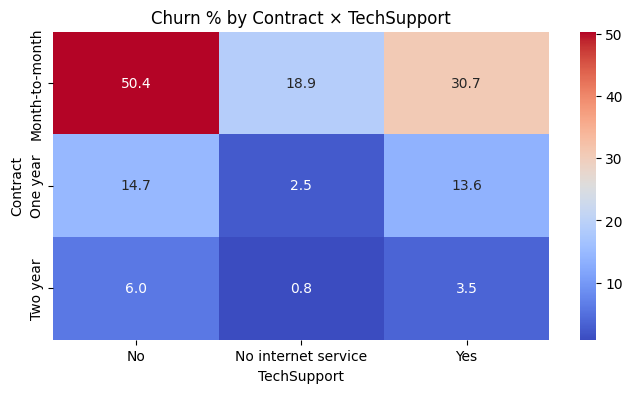

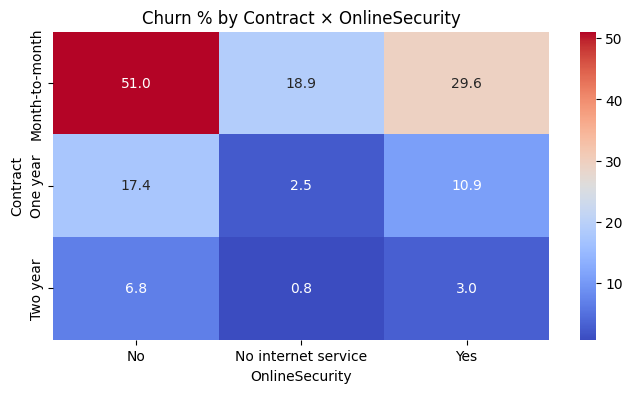

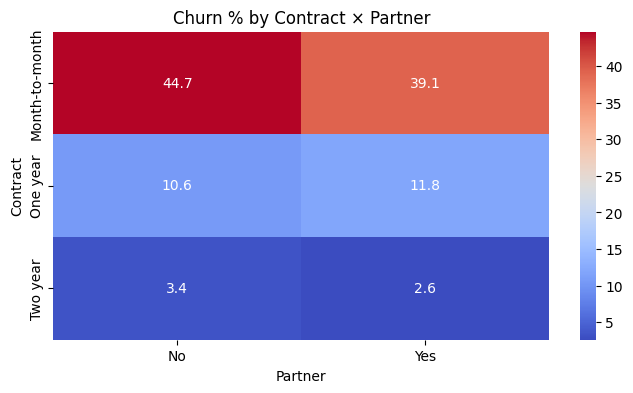

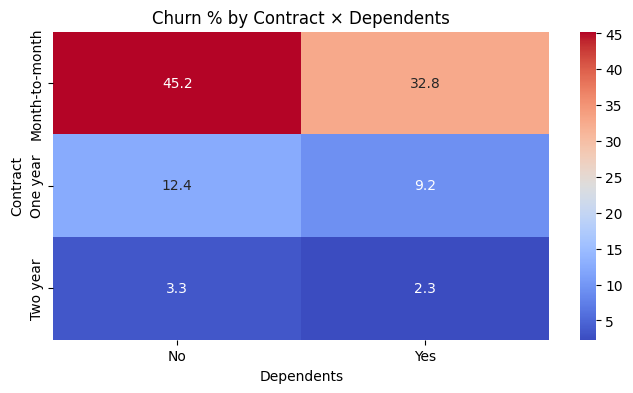

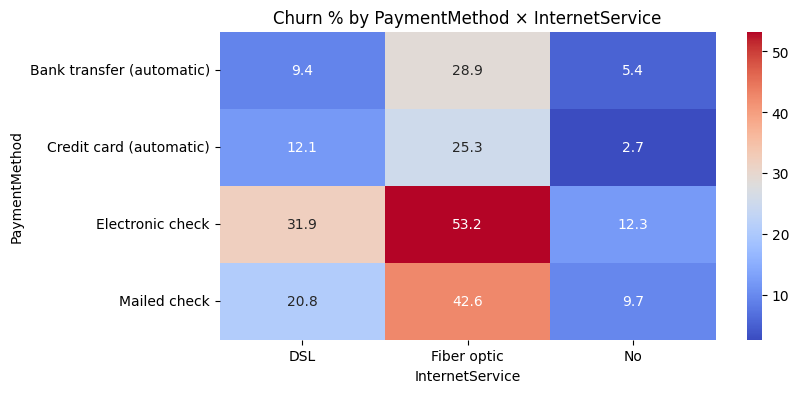

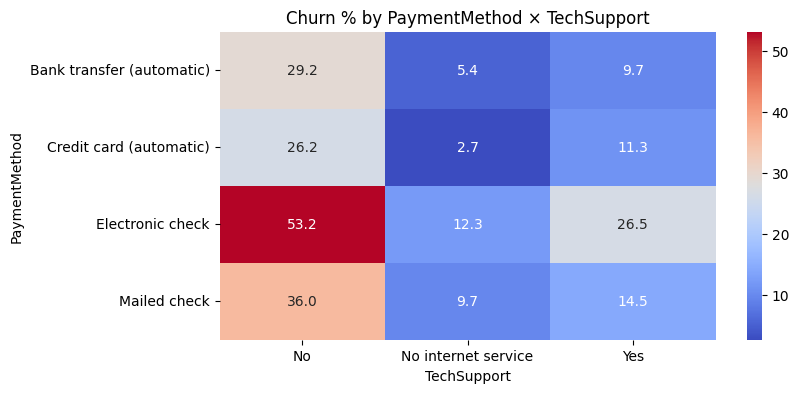

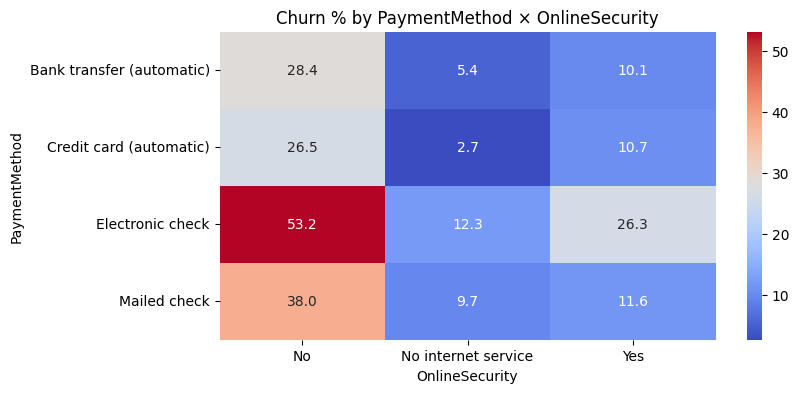

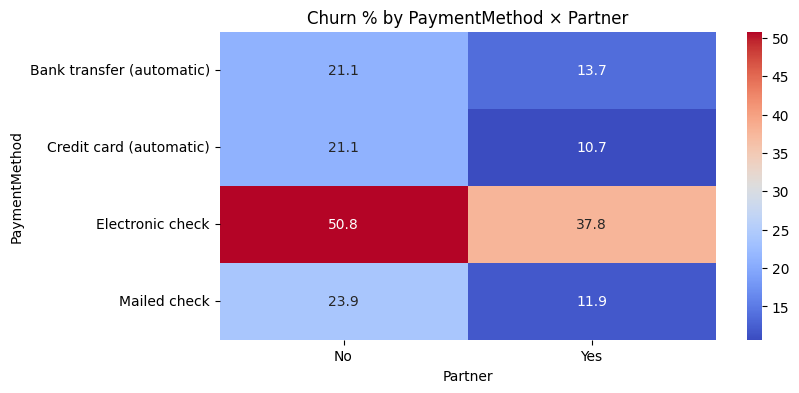

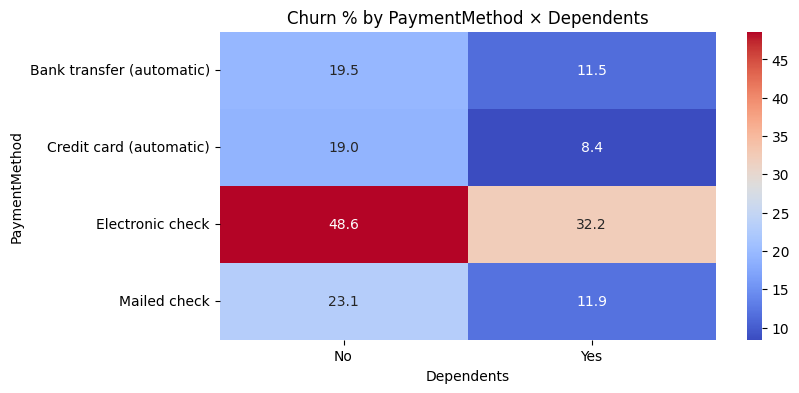

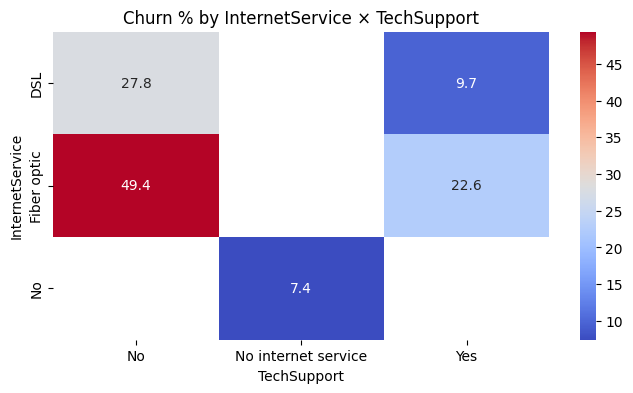

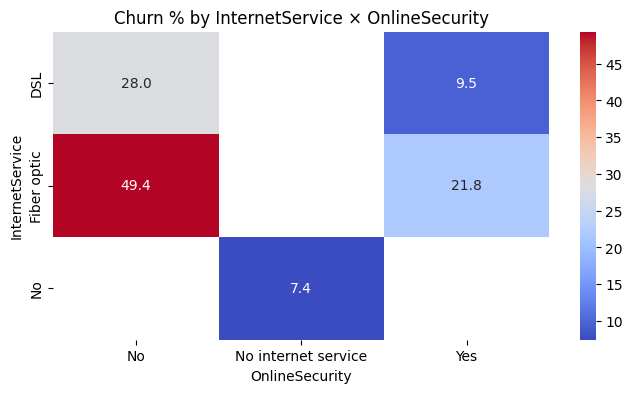

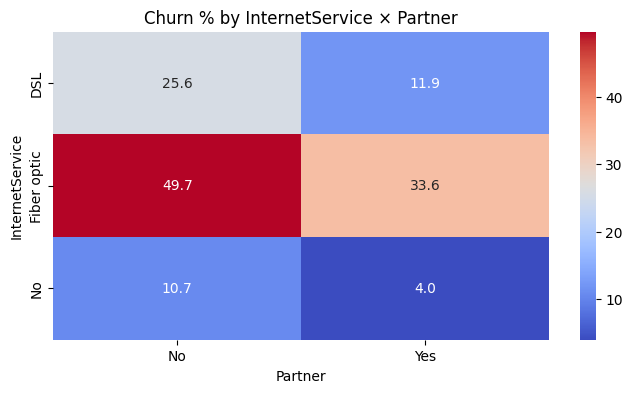

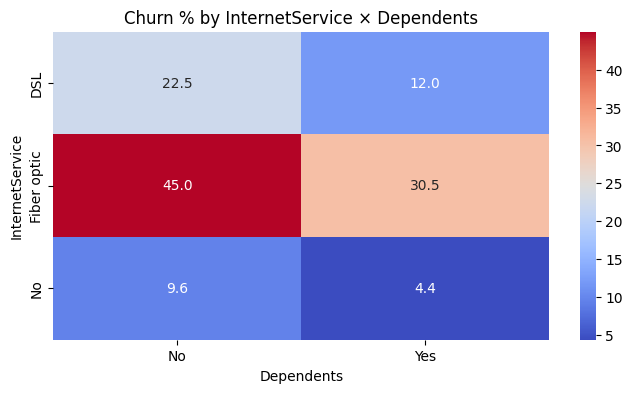

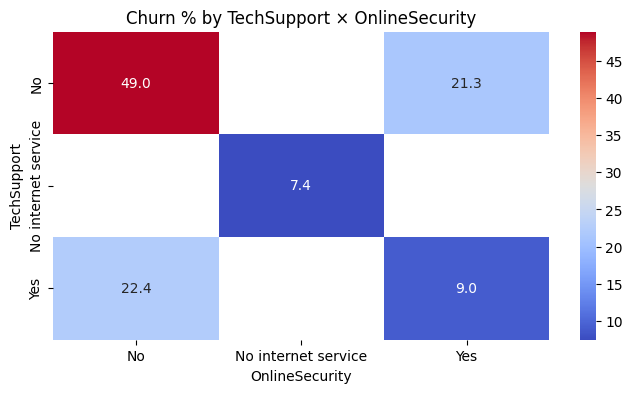

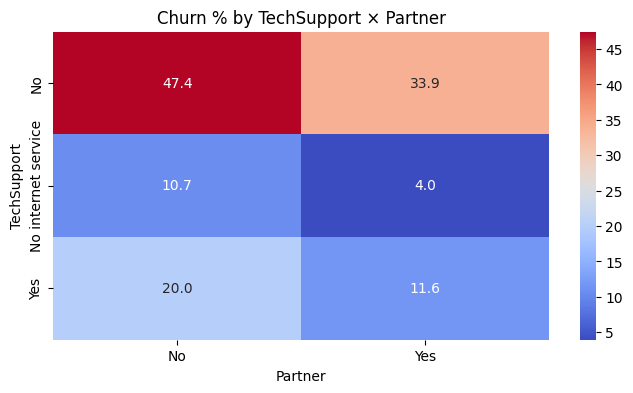

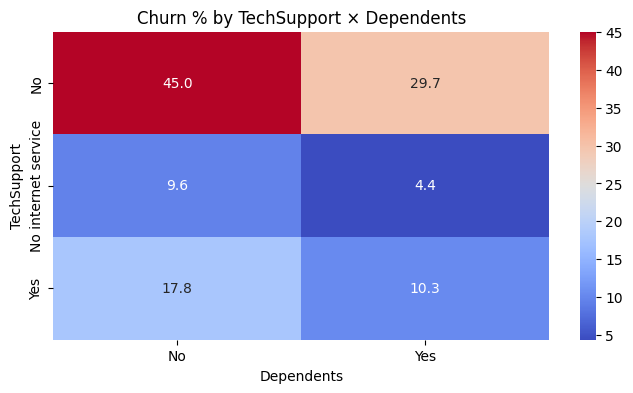

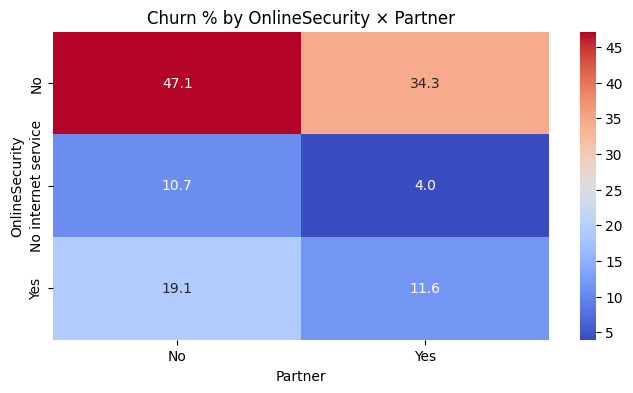

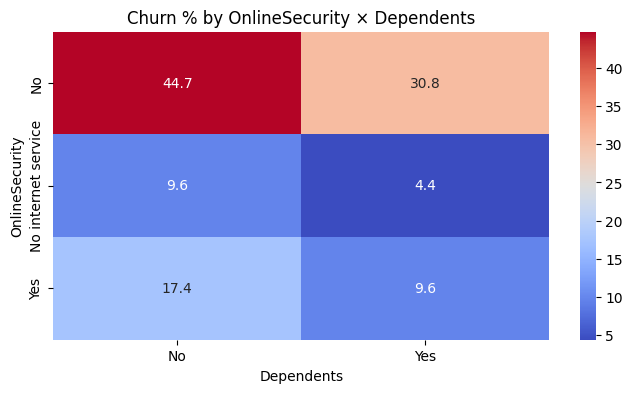

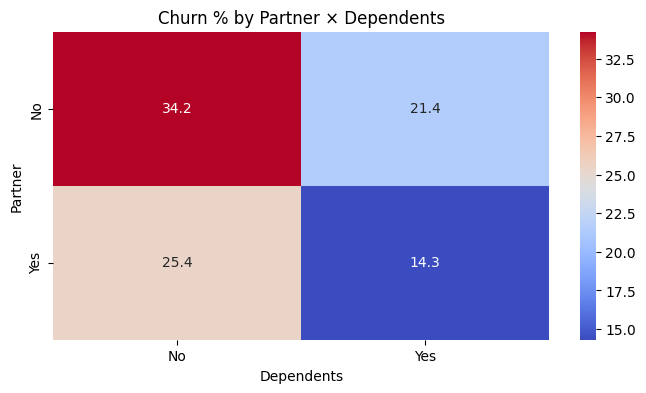

In [31]:
# Risk Segmentation - Explore Multiple Combinations

# Pairwise interactions
for i in range(len(important_cats)):

    for j in range(i+1, len(important_cats)):

        c1, c2 = important_cats[i], important_cats[j]
        risk_table = pd.crosstab(df[c1], df[c2],
                                 values=(df['Churn'] == 'Yes'), aggfunc='mean') * 100
        plt.figure(figsize=(8,4))
        sns.heatmap(risk_table, annot=True, fmt=".1f", cmap="coolwarm")
        plt.title(f"Churn % by {c1} × {c2}")
        plt.xlabel(c2)
        plt.ylabel(c1)
        plt.show()


- From these heatmaps, we can clearly see that churn is especially high for Month-to-Month contracts combined with Electronic Check or Fiber Optic service.
- This motivates us to do a deeper dive and rank these combinations quantitatively.”

# Multi-Dimensional Analysis

In [32]:
# Create bins for numerical features
df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72],
                            labels=['0-12m','13-24m','25-48m','49-72m'], right=True)

df['monthly_bin'] = pd.qcut(df['MonthlyCharges'], q=4,
                            labels=['Low','Medium','High','Very High'])
df['total_bin']   = pd.qcut(df['TotalCharges'], q=4,
                            labels=['Low','Medium','High','Very High'])

In [33]:
# Generate churn rate for multi-dimensional groups
group_cols = ['tenure_group', 'Contract', 'PaymentMethod', 'monthly_bin']
segment_churn = (df.groupby(group_cols)['Churn']
                   .apply(lambda x: (x == 'Yes').mean() * 100)
                   .reset_index(name='churn_rate'))


/tmp/ipython-input-1768097738.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [34]:
# Sort by churn_rate descending
segment_churn_sorted = segment_churn.sort_values(by='churn_rate', ascending=False)


In [35]:
# Display Top 10 risky segments
top_segments = segment_churn_sorted.head(10)

/tmp/ipython-input-3715690195.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




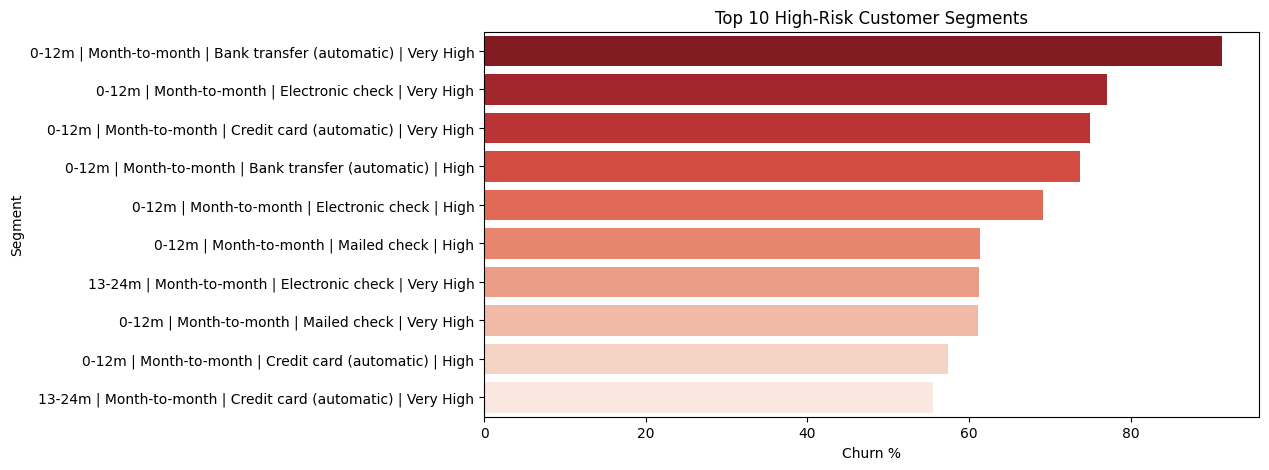

,tenure_group,Contract,PaymentMethod,monthly_bin,churn_rate
3,0-12m,Month-to-month,Bank transfer (automatic),Very High,91.30%
11,0-12m,Month-to-month,Electronic check,Very High,77.12%
7,0-12m,Month-to-month,Credit card (automatic),Very High,75.00%
2,0-12m,Month-to-month,Bank transfer (automatic),High,73.68%
10,0-12m,Month-to-month,Electronic check,High,69.17%
14,0-12m,Month-to-month,Mailed check,High,61.36%
59,13-24m,Month-to-month,Electronic check,Very High,61.21%
15,0-12m,Month-to-month,Mailed check,Very High,61.11%
6,0-12m,Month-to-month,Credit card (automatic),High,57.41%
55,13-24m,Month-to-month,Credit card (automatic),Very High,55.56%


In [36]:
plt.figure(figsize=(10,5))
sns.barplot(data=top_segments, x='churn_rate',
            y=top_segments.apply(lambda row: f"{row['tenure_group']} | {row['Contract']} | {row['PaymentMethod']} | {row['monthly_bin']}", axis=1),
            palette="Reds_r")
plt.xlabel("Churn %")
plt.ylabel("Segment")
plt.title("Top 10 High-Risk Customer Segments")
plt.show()

# top 10 segment
top_segments.style.background_gradient(
    subset=['churn_rate'], cmap='Reds'
).format({'churn_rate': '{:.2f}%'})



## Summary  

This EDA was not just about describing the dataset — **EDA is not descriptive, it gives perspective**.  
Throughout this notebook, I explored the Telco Customer Churn data from multiple angles — univariate, bivariate, pairwise interactions, and advanced segmentation — to really understand the story the data is telling and answer the key business questions.

---

### Key Insights  

1. **Most Loyal Customers**  
   - Customers with **long tenure, two-year contracts, and multiple add-ons** (like Tech Support, Online Security, and Device Protection) have the lowest churn.  
   - These customers are deeply invested in the services, making them less likely to leave.  

2. **Contract Type & Churn**  
   - Month-to-month contracts have the highest churn (unsurprisingly).  
   - Contract type is the **single most powerful churn driver** in the dataset.  

3. **Tenure & Early Warning Signs**  
   - Customers in the first 12 months (`tenure_group = 0-12m`) are at **highest risk of leaving** — an early lifecycle problem.  
   - Monitoring these new customers closely is critical for retention.  

4. **Payment Method & Risk**  
   - Electronic check users churn significantly more than other payment methods.  
   - **Notice how AutoPay methods appear in the Top-10 risky segments — this might look counterintuitive because they usually have lower churn rates overall.  
     But when combined with high monthly charges and month-to-month contracts, even these customers are leaving.**  
   - This tells us that **price sensitivity can override loyalty**.  

5. **Internet Service & Add-ons**  
   - Fiber optic users churn more than DSL users, especially on month-to-month plans.  
   - Customers who use fewer add-ons (like Tech Support or Online Security) are at higher risk — upselling these services could anchor retention.  

6. **Top-10 Risky Segments**  
   - The combination of **short tenure, high monthly charges, month-to-month contract, and electronic check payment** consistently shows the highest churn rates (50–65%).  
   - These are the **priority target customers** for any retention strategy.  

---

### Business Perspective  

EDA is about **turning data into actionable perspective**.  
If I had to take a decision based on this analysis, I would do this:

- **Short-Term Retention Campaign:**  
  - Target 0–12 month customers on month-to-month contracts with loyalty discounts or incentives to switch to longer-term contracts.  
  - Focus especially on **high monthly spenders** (High / Very High MonthlyCharges bins).  

- **Payment Method Migration:**  
  - Encourage electronic check users to switch to AutoPay or credit card payments.  
  - Offer a small incentive or one-time benefit to make the migration appealing.  

- **Fiber Optic Experience:**  
  - Investigate complaints or pricing issues for Fiber optic users.  
  - Consider mid-tier plans or bundled services to reduce churn.  

- **Proactive Add-On Upselling:**  
  - Customers without Tech Support or Online Security churn more.  
  - Upselling these services can act as a **retention anchor**.  

---

### Next Steps for Modeling  

1. **Feature Engineering:**  
   - Keep `tenure_group`, `monthly_bin`, and `total_bin` features.  
   - Create binary features like `HasTechSupport`, `HasOnlineSecurity`.  
   - Encode categorical variables properly for ML models.  

2. **Data Cleaning:**  
   - Ensure no missing values remain.  
   - Scale numerical columns if needed (for Logistic Regression or other algorithms).  

3. **Baseline & Advanced Models:**  
   - Start with Logistic Regression for interpretability.  
   - Try RandomForest and XGBoost for capturing non-linear interactions.  

4. **Business Simulation:**  
   - Score customers by churn probability.  
   - Simulate retention strategies:  
     - What if we offer discounts to high-risk groups?  
     - How much churn reduction could we expect?  

---

### Takeaway  

This notebook is **not just an EDA** — it’s a **data-driven business story**.  
It shows:

- Who is churning  
- Why they are churning  
- What actionable steps can reduce churn  

By focusing on high-risk segments, the company can **improve retention, stabilize revenue, and enhance customer satisfaction**.


---

🙏 **Thanks for reading!**  
I hope this notebook was as useful for you as it was for me in my ML learning journey.  
If you have questions or suggestions, feel free to connect with me.  

🔗 **My GitHub:** [Aman-sys-ui](https://github.com/Aman-sys-ui)